In [ ]:
# ================= INSTALL =================
!pip install inference supervision opencv-python-headless matplotlib --quiet


     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 105.7/105.7 kB 8.8 MB/s eta 0:00:00
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 68.6/68.6 kB 5.7 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 91.2/91.2 kB 7.6 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 99.4/99.4 kB 8.0 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.0/44.0 kB 3.4 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.6/56.6 kB 3.8 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 46.8/46.8 kB 3.7 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 42.2/42.2 kB 3.2 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
  Preparing metadata (setup.py) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 48.5/48.5 kB 4

In [ ]:
# ================= INSTALL (if not installed) =================
!pip install inference --quiet


Selected Image: Screenshot 2026-02-20 194426_png.rf.kFBlj5S5HteJG0XuTaXz.png


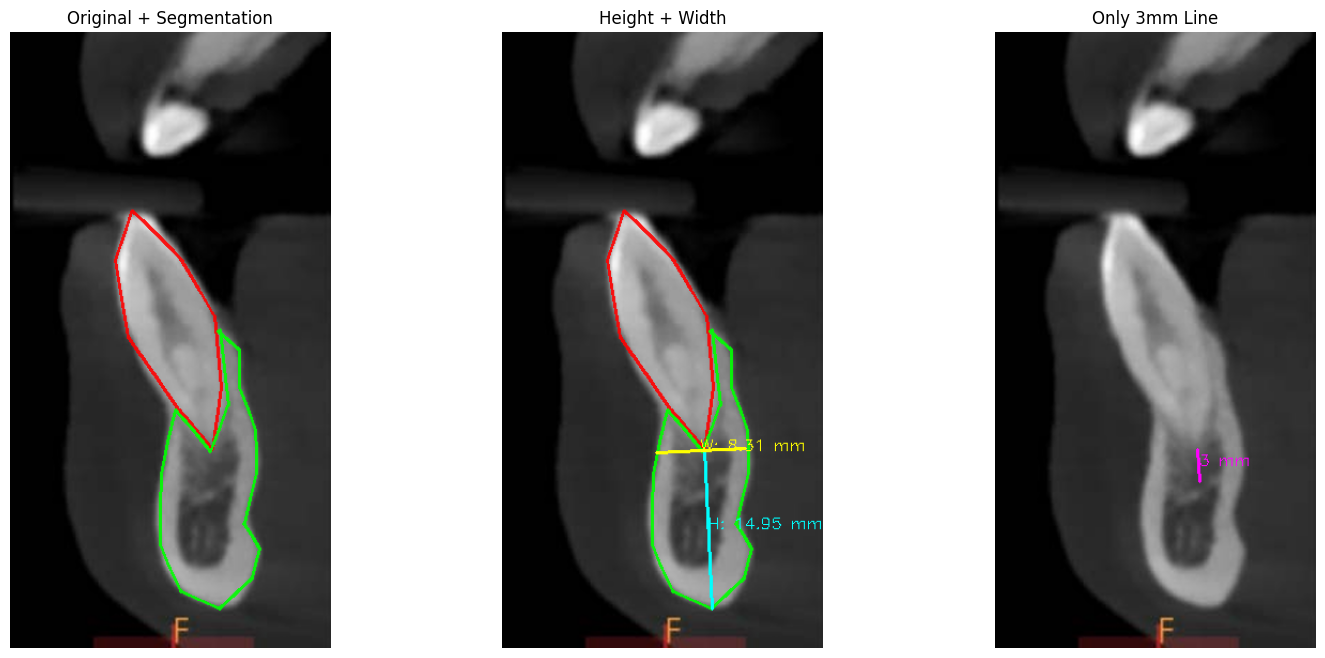

In [ ]:
# ================= INSTALL =================
!pip install inference --quiet

# ================= IMPORTS =================
import json
import cv2
import numpy as np
import os
import matplotlib.pyplot as plt
from inference import get_model

# ================= CONFIG =================
COCO_PATH = "/content/drive/MyDrive/teethimplant/teethimplant.coco/train/_annotations.coco.json"
IMAGE_FOLDER = "/content/drive/MyDrive/teethimplant/teethimplant.coco/train"

IMAGE_NUMBER = 5
WAVE_STRENGTH = 1
POINT_DENSITY = 3
PIXELS_PER_MM = 10

SEG_THICKNESS = 2
LINE_THICKNESS = 2
TEXT_SCALE = 0.5
TEXT_THICKNESS = 1

# ================= LOAD YOLO =================
yolo_model = get_model(
    model_id="nervecanal/6",
    api_key="luFuyH88RAQnCmLZoWCp"
)

# ================= LOAD COCO =================
with open(COCO_PATH) as f:
    coco = json.load(f)

# ================= GET IMAGE =================
image_files = sorted([
    f for f in os.listdir(IMAGE_FOLDER)
    if f.lower().endswith((".png", ".jpg", ".jpeg"))
])

selected_image_name = image_files[IMAGE_NUMBER - 1]
print("Selected Image:", selected_image_name)

image_id = None
for img in coco["images"]:
    if img["file_name"] == selected_image_name:
        image_id = img["id"]
        break

img_path = os.path.join(IMAGE_FOLDER, selected_image_name)
base_image = cv2.imread(img_path)
h, w = base_image.shape[:2]

# ================= BRUSH FUNCTION =================
def create_brush_contour(pts):
    pts = np.vstack([pts, pts[0]])
    dense_points = []

    for i in range(len(pts)-1):
        p1 = pts[i]
        p2 = pts[i+1]
        for t in np.linspace(0,1,POINT_DENSITY):
            dense_points.append((1-t)*p1 + t*p2)

    dense_points = np.array(dense_points)
    new_points = []

    for i in range(len(dense_points)):
        p = dense_points[i]
        prev_p = dense_points[i-1]
        next_p = dense_points[(i+1)%len(dense_points)]

        tangent = next_p - prev_p
        norm = np.array([-tangent[1], tangent[0]])
        norm = norm / (np.linalg.norm(norm)+1e-6)

        wave = np.sin(i*0.3) * WAVE_STRENGTH
        displaced = p + norm * wave

        displaced[0] = np.clip(displaced[0],0,w-1)
        displaced[1] = np.clip(displaced[1],0,h-1)

        new_points.append(displaced)

    return np.array(new_points,dtype=np.int32)

# ================= DRAW SEGMENTATION =================
image_no_line = base_image.copy()
overlay = image_no_line.copy()

tooth_bottom = None
bone_bottom = None
bone_points = []

for ann in coco["annotations"]:
    if ann["image_id"] != image_id:
        continue

    if isinstance(ann["segmentation"], dict):
        continue

    pts = np.array(ann["segmentation"][0]).reshape(-1,2)
    bottom_point = pts[np.argmax(pts[:,1])]

    if ann["category_id"] == 3:
        tooth_bottom = bottom_point
    elif ann["category_id"] == 1:
        bone_bottom = bottom_point
        bone_points.extend(pts)

    brush_contour = create_brush_contour(pts)

    if ann["category_id"] == 1:
        color = (0,255,0)
    elif ann["category_id"] == 2:
        color = (255,0,0)
    elif ann["category_id"] == 3:
        color = (0,0,255)
    else:
        color = (255,255,0)

    cv2.polylines(overlay,[brush_contour],True,color,SEG_THICKNESS)

image_no_line = cv2.addWeighted(overlay,0.9,image_no_line,0.1,0)

# ================= YOLO DETECTION =================
results = yolo_model.infer(img_path)[0]
for pred in results.predictions:
    x,y = int(pred.x), int(pred.y)
    bw,bh = int(pred.width), int(pred.height)
    x1,y1 = int(x-bw/2), int(y-bh/2)
    x2,y2 = int(x+bw/2), int(y+bh/2)
    cv2.rectangle(image_no_line,(x1,y1),(x2,y2),(0,0,255),2)

# ================= IMAGE WITH LINES =================
image_with_lines = image_no_line.copy()

if tooth_bottom is not None and bone_bottom is not None:

    # -------- HEIGHT --------
    cv2.line(image_with_lines,
             tuple(tooth_bottom.astype(int)),
             tuple(bone_bottom.astype(int)),
             (255,255,0),
             LINE_THICKNESS)

    height_px = np.linalg.norm(tooth_bottom - bone_bottom)
    height_mm = height_px / PIXELS_PER_MM

    mid_height = ((tooth_bottom + bone_bottom)/2).astype(int)

    cv2.putText(image_with_lines,
                f"H: {round(height_mm,2)} mm",
                tuple(mid_height),
                cv2.FONT_HERSHEY_SIMPLEX,
                TEXT_SCALE,
                (255,255,0),
                TEXT_THICKNESS)

    # -------- TRUE FULL BONE WIDTH (EDGE-TO-EDGE) --------
    # -------- WIDTH AT TOOTH BOTTOM (STRICTLY INSIDE BONE) --------

    direction = bone_bottom - tooth_bottom
    direction = direction / (np.linalg.norm(direction) + 1e-6)

    perp = np.array([-direction[1], direction[0]])

    # Create bone mask
    bone_mask = np.zeros((h, w), dtype=np.uint8)

    for ann in coco["annotations"]:
        if ann["image_id"] == image_id and ann["category_id"] == 1:
            if not isinstance(ann["segmentation"], dict):
                pts = np.array(ann["segmentation"][0]).reshape(-1,2).astype(int)
                cv2.fillPoly(bone_mask, [pts], 255)

    def walk_until_edge(start, vec):
        current = start.astype(float)
        last_valid = current.copy()

        while True:
            current = current + vec
            x, y = int(round(current[0])), int(round(current[1]))

            if x < 0 or x >= w or y < 0 or y >= h:
                break
            if bone_mask[y, x] == 0:
                break

            last_valid = current.copy()

        return last_valid
    start_point = tooth_bottom.astype(float) + direction

    edge_pos = walk_until_edge(start_point, perp)
    edge_neg = walk_until_edge(start_point, -perp)

    edge_pos = edge_pos.astype(int)
    edge_neg = edge_neg.astype(int)

    # Draw width line
    cv2.line(image_with_lines,
            tuple(edge_neg),
            tuple(edge_pos),
            (0,255,255),
            LINE_THICKNESS)

    width_px = np.linalg.norm(edge_pos - edge_neg)
    width_mm = width_px / PIXELS_PER_MM

    mid_width = ((edge_pos + edge_neg) / 2).astype(int)

    cv2.putText(image_with_lines,
                f"W: {round(width_mm,2)} mm",
                tuple(mid_width),
                cv2.FONT_HERSHEY_SIMPLEX,
                TEXT_SCALE,
                (0,255,255),
                TEXT_THICKNESS)
    # ================= NEW IMAGE : 3mm HEIGHT LINE =================

    image_3mm = base_image.copy()

    if tooth_bottom is not None and bone_bottom is not None:

        # Height direction
        direction = bone_bottom - tooth_bottom
        direction = direction / (np.linalg.norm(direction) + 1e-6)

        # 3mm = 30 pixels (since 10px = 1mm)
        length_px = 3 * PIXELS_PER_MM

        end_point = tooth_bottom + direction * length_px
        end_point = end_point.astype(int)

        # Draw line
        cv2.line(image_3mm,
                tuple(tooth_bottom.astype(int)),
                tuple(end_point),
                (255,0,255),
                LINE_THICKNESS)

        # Label
        mid_point = ((tooth_bottom + end_point) / 2).astype(int)

        cv2.putText(image_3mm,
                    "3 mm",
                    tuple(mid_point),
                    cv2.FONT_HERSHEY_SIMPLEX,
                    TEXT_SCALE,
                    (255,0,255),
                    TEXT_THICKNESS)
# ================= SHOW =================
plt.figure(figsize=(18,8))

plt.subplot(1,3,1)
plt.imshow(cv2.cvtColor(image_no_line,cv2.COLOR_BGR2RGB))
plt.title("Original + Segmentation")
plt.axis("off")

plt.subplot(1,3,2)
plt.imshow(cv2.cvtColor(image_with_lines,cv2.COLOR_BGR2RGB))
plt.title("Height + Width")
plt.axis("off")

plt.subplot(1,3,3)
plt.imshow(cv2.cvtColor(image_3mm,cv2.COLOR_BGR2RGB))
plt.title("Only 3mm Line")
plt.axis("off")

plt.show()

Selected: Screenshot 2026-02-20 194426_png.rf.kFBlj5S5HteJG0XuTaXz.png

===== IMPLANT SECTION =====
Section Height: 14.1 mm
Section Width: 8.3 mm
Recommended Width: 5.3 mm
Recommended Height: 14.1 mm
Best Match: ('Straumann', 4.0, 14)


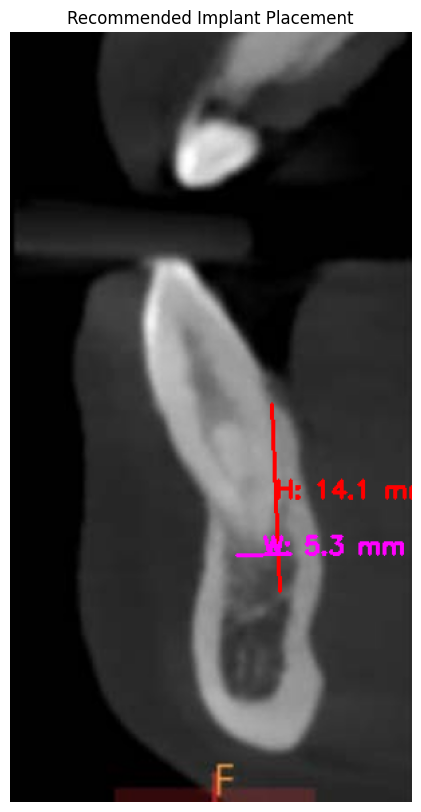

In [ ]:
# ================= INSTALL =================
!pip install inference --quiet

# ================= IMPORTS =================
import json
import cv2
import numpy as np
import os
import matplotlib.pyplot as plt
from inference import get_model

# ================= CONFIG =================
COCO_PATH = "/content/drive/MyDrive/teethimplant/teethimplant.coco/train/_annotations.coco.json"
IMAGE_FOLDER = "/content/drive/MyDrive/teethimplant/teethimplant.coco/train"

IMAGE_NUMBER = 5
PIXELS_PER_MM = 10
PX_TO_MM = 1 / PIXELS_PER_MM
MM_TO_PX = PIXELS_PER_MM

SEG_THICKNESS = 2
LINE_THICKNESS = 2
TEXT_SCALE = 0.5
TEXT_THICKNESS = 1

# ================= IMPLANT CATALOG =================
def load_implant_catalog():
    return {
        "Straumann": [(3.5,8),(3.5,10),(3.5,12),(3.5,14),(3.5,16),(3.5,18),
                      (4.0,6),(4.0,8),(4.0,10),(4.0,12),(4.0,14),(4.0,16),(4.0,18)],
        "Nobel Biocare": [(3.0,10),(3.0,13),(3.5,10),(3.5,13),(4.3,10),(4.3,13)],
        "Noris": [(3.3,8),(3.3,10),(3.75,8),(3.75,10),(4.2,8),(4.2,10)],
        "Osstem": [(3.0,10),(3.5,10),(4.3,10),(5.0,10)]
    }

def recommend_implant(section_height_mm,
                      section_width_mm,
                      nerve_mask,
                      top,
                      PX_TO_MM,
                      MM_TO_PX,
                      implant_catalog):

    implant_width_mm = max(section_width_mm - 3, 0)

    ys, xs = np.where(nerve_mask == 1)

    if len(ys) > 0:
        nerve_top_y = np.min(ys)
        safe_y = nerve_top_y - (2 * MM_TO_PX)
        implant_height_px = abs(safe_y - top[1])
        implant_height_mm = implant_height_px * PX_TO_MM
    else:
        implant_height_mm = section_height_mm

    implant_height_mm = max(implant_height_mm, 0)

    best_match = None
    best_error = float("inf")

    for company, implants in implant_catalog.items():
        for dia, length in implants:
            if dia <= implant_width_mm and length <= implant_height_mm:
                error = abs(dia - implant_width_mm) + abs(length - implant_height_mm)
                if error < best_error:
                    best_error = error
                    best_match = (company, dia, length)

    return implant_width_mm, implant_height_mm, best_match

# ================= LOAD DATA =================
with open(COCO_PATH) as f:
    coco = json.load(f)

image_files = sorted([f for f in os.listdir(IMAGE_FOLDER)
                      if f.lower().endswith((".png",".jpg",".jpeg"))])

selected_image_name = image_files[IMAGE_NUMBER-1]
print("Selected:", selected_image_name)

img_path = os.path.join(IMAGE_FOLDER, selected_image_name)
image = cv2.imread(img_path)
h,w = image.shape[:2]

image_id = None
for img in coco["images"]:
    if img["file_name"] == selected_image_name:
        image_id = img["id"]
        break

# ================= EXTRACT MASKS =================
tooth_bottom = None
bone_bottom = None
bone_top = None

bone_mask = np.zeros((h,w), dtype=np.uint8)
nerve_mask = np.zeros((h,w), dtype=np.uint8)

for ann in coco["annotations"]:
    if ann["image_id"] != image_id:
        continue

    if isinstance(ann["segmentation"], dict):
        continue

    pts = np.array(ann["segmentation"][0]).reshape(-1,2).astype(int)

    if ann["category_id"] == 3:
        tooth_bottom = pts[np.argmax(pts[:,1])]
    elif ann["category_id"] == 1:
        bone_bottom = pts[np.argmax(pts[:,1])]
        bone_top = pts[np.argmin(pts[:,1])]
        cv2.fillPoly(bone_mask,[pts],1)
    elif ann["category_id"] == 2:
        cv2.fillPoly(nerve_mask,[pts],1)

# ================= HEIGHT DIRECTION =================
direction = bone_bottom - tooth_bottom
direction = direction / (np.linalg.norm(direction)+1e-6)

# ================= 3MM LINE =================
length_px = 3 * MM_TO_PX
bottom_3mm = tooth_bottom + direction * length_px
bottom_3mm = bottom_3mm.astype(int)

# ================= WIDTH AT 1PX BELOW TOOTH =================
perp = np.array([-direction[1], direction[0]])
perp = perp / (np.linalg.norm(perp)+1e-6)

start_point = tooth_bottom.astype(float) + direction

def walk(start, vec):
    cur = start.copy()
    last = cur.copy()
    while True:
        cur += vec
        x,y = int(round(cur[0])), int(round(cur[1]))
        if x<0 or x>=w or y<0 or y>=h or bone_mask[y,x]==0:
            break
        last = cur.copy()
    return last

edge1 = walk(start_point, perp)
edge2 = walk(start_point, -perp)

width_px = np.linalg.norm(edge1-edge2)
section_width_mm = width_px * PX_TO_MM

# ================= SECTION HEIGHT =================
section_height_px = abs(bottom_3mm[1] - bone_top[1])
section_height_mm = section_height_px * PX_TO_MM

# ================= IMPLANT RECOMMEND =================
catalog = load_implant_catalog()

implant_width_mm, implant_height_mm, best = recommend_implant(
    section_height_mm,
    section_width_mm,
    nerve_mask,
    bone_top,
    PX_TO_MM,
    MM_TO_PX,
    catalog
)

print("\n===== IMPLANT SECTION =====")
print("Section Height:", round(section_height_mm,2),"mm")
print("Section Width:", round(section_width_mm,2),"mm")
print("Recommended Width:", round(implant_width_mm,2),"mm")
print("Recommended Height:", round(implant_height_mm,2),"mm")
print("Best Match:", best)

# ================= DRAW RECOMMENDED IMPLANT =================

# ================= DRAW RECOMMENDED IMPLANT =================

implant_image = image.copy()

if best is not None:

    company, dia_mm, length_mm = best

    # Convert to pixels
    implant_height_px = implant_height_mm * MM_TO_PX
    implant_width_px = dia_mm * MM_TO_PX

    # Height direction
    direction = bone_bottom - tooth_bottom
    direction = direction / (np.linalg.norm(direction) + 1e-6)

    perp = np.array([-direction[1], direction[0]])
    perp = perp / (np.linalg.norm(perp) + 1e-6)

    # Implant TOP = bone crest
    implant_top = bone_top.astype(float)

    # Implant bottom
    implant_bottom = implant_top + direction * implant_height_px

    # -------- WIDTH SAME AS YOUR ENTRY LEVEL --------
    # Use same start point you used earlier
    start_point = tooth_bottom.astype(float) + direction

    # Center implant width at start_point
    center = start_point

    half_width = implant_width_px / 2

    edge1 = center + perp * half_width
    edge2 = center - perp * half_width

    # Draw height line
    # ---------- DRAW HEIGHT ----------
    cv2.line(implant_image,
            tuple(implant_top.astype(int)),
            tuple(implant_bottom.astype(int)),
            (0,0,255),
            2)

    mid_height = ((implant_top + implant_bottom) / 2).astype(int)

    cv2.putText(implant_image,
                f"H: {round(implant_height_mm,2)} mm",
                tuple(mid_height),
                cv2.FONT_HERSHEY_SIMPLEX,
                0.6,
                (0,0,255),
                2)

    # ---------- DRAW WIDTH ----------
    cv2.line(implant_image,
            tuple(edge1.astype(int)),
            tuple(edge2.astype(int)),
            (255,0,255),
            2)

    mid_width = ((edge1 + edge2) / 2).astype(int)

    cv2.putText(implant_image,
                f"W: {round(implant_width_mm,2)} mm",
                tuple(mid_width),
                cv2.FONT_HERSHEY_SIMPLEX,
                0.6,
                (255,0,255),
                2)

# ================= SHOW =================
plt.figure(figsize=(6,10))
plt.imshow(cv2.cvtColor(implant_image,cv2.COLOR_BGR2RGB))
plt.title("Recommended Implant Placement")
plt.axis("off")
plt.show()

Selected: Screenshot 2026-02-21 223214_png.rf.H9isQLnhbia0CEA21RSA.png

===== IMPLANT SECTION =====
Section Height: 9.6 mm
Section Width: 0.0 mm
Recommended Width: 0 mm
Recommended Height: 9.6 mm
Best Match: None


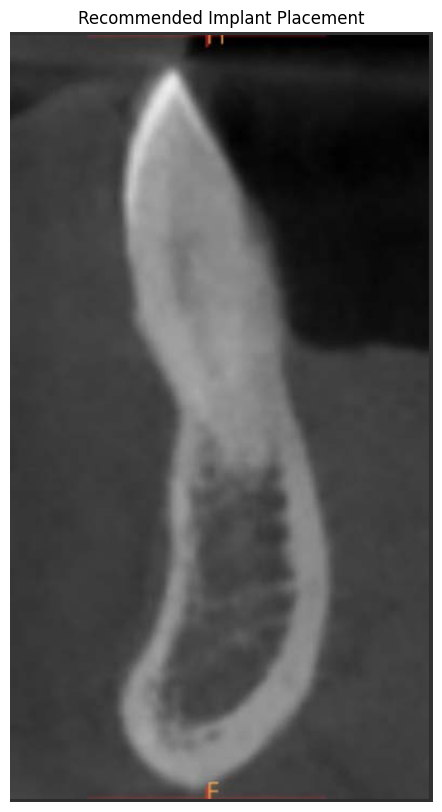

In [ ]:
# ================= INSTALL =================
!pip install inference --quiet

# ================= IMPORTS =================
import json
import cv2
import numpy as np
import os
import matplotlib.pyplot as plt
from inference import get_model

# ================= CONFIG =================
COCO_PATH = "/content/drive/MyDrive/teethimplant/_annotations.coco.json"
IMAGE_FOLDER = "/content/drive/MyDrive/teethimplant/"

IMAGE_NUMBER = 7
PIXELS_PER_MM = 10
PX_TO_MM = 1 / PIXELS_PER_MM
MM_TO_PX = PIXELS_PER_MM

SEG_THICKNESS = 2
LINE_THICKNESS = 2
TEXT_SCALE = 0.5
TEXT_THICKNESS = 1

# ================= IMPLANT CATALOG =================
def load_implant_catalog():
    return {
        "Straumann": [(3.5,8),(3.5,10),(3.5,12),(3.5,14),(3.5,16),(3.5,18),
                      (4.0,6),(4.0,8),(4.0,10),(4.0,12),(4.0,14),(4.0,16),(4.0,18)],
        "Nobel Biocare": [(3.0,10),(3.0,13),(3.5,10),(3.5,13),(4.3,10),(4.3,13)],
        "Noris": [(3.3,8),(3.3,10),(3.75,8),(3.75,10),(4.2,8),(4.2,10)],
        "Osstem": [(3.0,10),(3.5,10),(4.3,10),(5.0,10)]
    }

def recommend_implant(section_height_mm,
                      section_width_mm,
                      nerve_mask,
                      top,
                      PX_TO_MM,
                      MM_TO_PX,
                      implant_catalog):

    implant_width_mm = max(section_width_mm - 3, 0)

    ys, xs = np.where(nerve_mask == 1)

    if len(ys) > 0:
        nerve_top_y = np.min(ys)
        safe_y = nerve_top_y - (2 * MM_TO_PX)
        implant_height_px = abs(safe_y - top[1])
        implant_height_mm = implant_height_px * PX_TO_MM
    else:
        implant_height_mm = section_height_mm

    implant_height_mm = max(implant_height_mm, 0)

    best_match = None
    best_error = float("inf")

    for company, implants in implant_catalog.items():
        for dia, length in implants:
            if dia <= implant_width_mm and length <= implant_height_mm:
                error = abs(dia - implant_width_mm) + abs(length - implant_height_mm)
                if error < best_error:
                    best_error = error
                    best_match = (company, dia, length)

    return implant_width_mm, implant_height_mm, best_match

# ================= LOAD DATA =================
with open(COCO_PATH) as f:
    coco = json.load(f)

image_files = sorted([f for f in os.listdir(IMAGE_FOLDER)
                      if f.lower().endswith((".png",".jpg",".jpeg"))])

selected_image_name = image_files[IMAGE_NUMBER-1]
print("Selected:", selected_image_name)

img_path = os.path.join(IMAGE_FOLDER, selected_image_name)
image = cv2.imread(img_path)
h,w = image.shape[:2]

image_id = None
for img in coco["images"]:
    if img["file_name"] == selected_image_name:
        image_id = img["id"]
        break

# ================= EXTRACT MASKS =================
tooth_bottom = None
bone_bottom = None
bone_top = None

bone_mask = np.zeros((h,w), dtype=np.uint8)
nerve_mask = np.zeros((h,w), dtype=np.uint8)

for ann in coco["annotations"]:
    if ann["image_id"] != image_id:
        continue

    if isinstance(ann["segmentation"], dict):
        continue

    pts = np.array(ann["segmentation"][0]).reshape(-1,2).astype(int)

    if ann["category_id"] == 3:
        tooth_bottom = pts[np.argmax(pts[:,1])]
    elif ann["category_id"] == 1:
        bone_bottom = pts[np.argmax(pts[:,1])]
        bone_top = pts[np.argmin(pts[:,1])]
        cv2.fillPoly(bone_mask,[pts],1)
    elif ann["category_id"] == 2:
        cv2.fillPoly(nerve_mask,[pts],1)

# ================= HEIGHT DIRECTION =================
direction = bone_bottom - tooth_bottom
direction = direction / (np.linalg.norm(direction)+1e-6)

# ================= 3MM LINE =================
length_px = 3 * MM_TO_PX
bottom_3mm = tooth_bottom + direction * length_px
bottom_3mm = bottom_3mm.astype(int)

# ================= WIDTH AT 1PX BELOW TOOTH =================
perp = np.array([-direction[1], direction[0]])
perp = perp / (np.linalg.norm(perp)+1e-6)

start_point = tooth_bottom.astype(float) + direction

def walk(start, vec):
    cur = start.copy()
    last = cur.copy()
    while True:
        cur += vec
        x,y = int(round(cur[0])), int(round(cur[1]))
        if x<0 or x>=w or y<0 or y>=h or bone_mask[y,x]==0:
            break
        last = cur.copy()
    return last

edge1 = walk(start_point, perp)
edge2 = walk(start_point, -perp)

width_px = np.linalg.norm(edge1-edge2)
section_width_mm = width_px * PX_TO_MM

# ================= SECTION HEIGHT =================
section_height_px = abs(bottom_3mm[1] - bone_top[1])
section_height_mm = section_height_px * PX_TO_MM

# ================= IMPLANT RECOMMEND =================
catalog = load_implant_catalog()

implant_width_mm, implant_height_mm, best = recommend_implant(
    section_height_mm,
    section_width_mm,
    nerve_mask,
    bone_top,
    PX_TO_MM,
    MM_TO_PX,
    catalog
)

print("\n===== IMPLANT SECTION =====")
print("Section Height:", round(section_height_mm,2),"mm")
print("Section Width:", round(section_width_mm,2),"mm")
print("Recommended Width:", round(implant_width_mm,2),"mm")
print("Recommended Height:", round(implant_height_mm,2),"mm")
print("Best Match:", best)

# ================= DRAW RECOMMENDED IMPLANT =================

# ================= DRAW RECOMMENDED IMPLANT =================

implant_image = image.copy()

if best is not None:

    company, dia_mm, length_mm = best

    # Convert to pixels
    implant_height_px = implant_height_mm * MM_TO_PX
    implant_width_px = dia_mm * MM_TO_PX

    # Height direction
    direction = bone_bottom - tooth_bottom
    direction = direction / (np.linalg.norm(direction) + 1e-6)

    perp = np.array([-direction[1], direction[0]])
    perp = perp / (np.linalg.norm(perp) + 1e-6)

    # Implant TOP = bone crest
    implant_top = bone_top.astype(float)

    # Implant bottom
    implant_bottom = implant_top + direction * implant_height_px

    # -------- WIDTH SAME AS YOUR ENTRY LEVEL --------
    # Use same start point you used earlier
    start_point = tooth_bottom.astype(float) + direction

    # Center implant width at start_point
    center = start_point

    half_width = implant_width_px / 2

    edge1 = center + perp * half_width
    edge2 = center - perp * half_width

    # Draw height line
    # ---------- DRAW HEIGHT ----------
    cv2.line(implant_image,
            tuple(implant_top.astype(int)),
            tuple(implant_bottom.astype(int)),
            (0,0,255),
            2)

    mid_height = ((implant_top + implant_bottom) / 2).astype(int)

    cv2.putText(implant_image,
                f"H: {round(implant_height_mm,2)} mm",
                tuple(mid_height),
                cv2.FONT_HERSHEY_SIMPLEX,
                0.6,
                (0,0,255),
                2)

    # ---------- DRAW WIDTH ----------
    cv2.line(implant_image,
            tuple(edge1.astype(int)),
            tuple(edge2.astype(int)),
            (255,0,255),
            2)

    mid_width = ((edge1 + edge2) / 2).astype(int)

    cv2.putText(implant_image,
                f"W: {round(implant_width_mm,2)} mm",
                tuple(mid_width),
                cv2.FONT_HERSHEY_SIMPLEX,
                0.6,
                (255,0,255),
                2)

# ================= SHOW =================
plt.figure(figsize=(6,10))
plt.imshow(cv2.cvtColor(implant_image,cv2.COLOR_BGR2RGB))
plt.title("Recommended Implant Placement")
plt.axis("off")
plt.show()

Selected Image: Screenshot 2026-02-21 223136_png.rf.UNP3b3KncQ8zNz10DUOZ.png


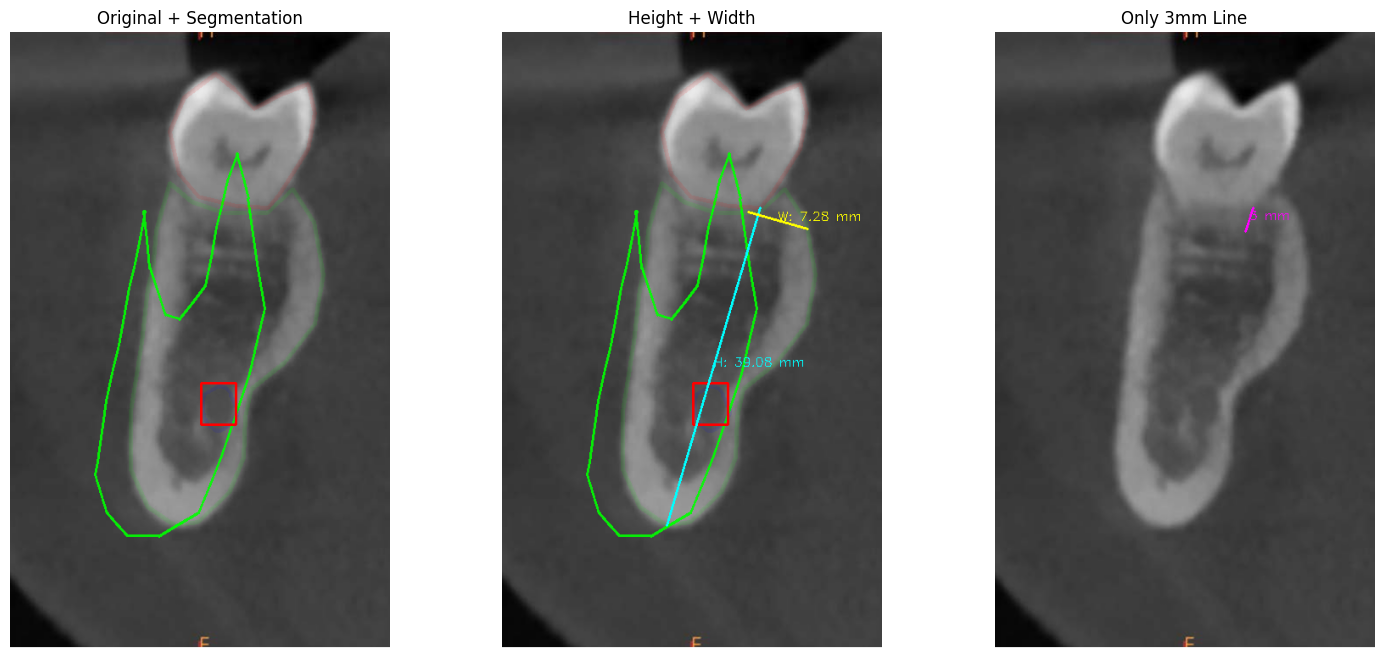

In [ ]:
# ================= INSTALL =================
!pip install inference --quiet

# ================= IMPORTS =================
import json
import cv2
import numpy as np
import os
import matplotlib.pyplot as plt
from inference import get_model

# ================= CONFIG =================
COCO_PATH = "/content/drive/MyDrive/teethimplant/_annotations.coco.json"
IMAGE_FOLDER = "/content/drive/MyDrive/teethimplant/"

IMAGE_NUMBER = 5
WAVE_STRENGTH = 1
POINT_DENSITY = 3
PIXELS_PER_MM = 10

SEG_THICKNESS = 2
LINE_THICKNESS = 2
TEXT_SCALE = 0.5
TEXT_THICKNESS = 1

# ================= LOAD YOLO =================
yolo_model = get_model(
    model_id="nervecanal/6",
    api_key="luFuyH88RAQnCmLZoWCp"
)

# ================= LOAD COCO =================
with open(COCO_PATH) as f:
    coco = json.load(f)

# ================= GET IMAGE =================
image_files = sorted([
    f for f in os.listdir(IMAGE_FOLDER)
    if f.lower().endswith((".png", ".jpg", ".jpeg"))
])

selected_image_name = image_files[IMAGE_NUMBER - 1]
print("Selected Image:", selected_image_name)

image_id = None
for img in coco["images"]:
    if img["file_name"] == selected_image_name:
        image_id = img["id"]
        break

img_path = os.path.join(IMAGE_FOLDER, selected_image_name)
base_image = cv2.imread(img_path)
h, w = base_image.shape[:2]

# ================= BRUSH FUNCTION =================
def create_brush_contour(pts):
    pts = np.vstack([pts, pts[0]])
    dense_points = []

    for i in range(len(pts)-1):
        p1 = pts[i]
        p2 = pts[i+1]
        for t in np.linspace(0,1,POINT_DENSITY):
            dense_points.append((1-t)*p1 + t*p2)

    dense_points = np.array(dense_points)
    new_points = []

    for i in range(len(dense_points)):
        p = dense_points[i]
        prev_p = dense_points[i-1]
        next_p = dense_points[(i+1)%len(dense_points)]

        tangent = next_p - prev_p
        norm = np.array([-tangent[1], tangent[0]])
        norm = norm / (np.linalg.norm(norm)+1e-6)

        wave = np.sin(i*0.3) * WAVE_STRENGTH
        displaced = p + norm * wave

        displaced[0] = np.clip(displaced[0],0,w-1)
        displaced[1] = np.clip(displaced[1],0,h-1)

        new_points.append(displaced)

    return np.array(new_points,dtype=np.int32)

# ================= DRAW SEGMENTATION =================
image_no_line = base_image.copy()
overlay = image_no_line.copy()

# ================= SEGMENTATION IMAGE (BRUSH SAFE) =================

image_no_line = base_image.copy()

bone_mask = np.zeros((h,w), dtype=np.uint8)
nerve_mask = np.zeros((h,w), dtype=np.uint8)

tooth_bottom = None
bone_bottom = None
bone_top = None

for ann in coco["annotations"]:
    if ann["image_id"] != image_id:
        continue

    cat = ann["category_id"]

    # -------- RLE (BRUSH TOOL) --------
    if isinstance(ann["segmentation"], dict):

        rle = ann["segmentation"]
        mask = maskUtils.decode(rle)

        if cat == 1:
            bone_mask = np.maximum(bone_mask, mask)
        elif cat == 2:
            nerve_mask = np.maximum(nerve_mask, mask)

        contours, _ = cv2.findContours(mask.astype(np.uint8),
                                       cv2.RETR_EXTERNAL,
                                       cv2.CHAIN_APPROX_SIMPLE)

        for cnt in contours:
            if cat == 1:
                cv2.drawContours(image_no_line,[cnt],-1,(0,255,0),3)
            elif cat == 2:
                cv2.drawContours(image_no_line,[cnt],-1,(255,0,0),3)

    # -------- POLYGON (TOOTH / BONE) --------
    else:
        pts = np.array(ann["segmentation"][0]).reshape(-1,2).astype(int)

        if cat == 3:
            tooth_bottom = pts[np.argmax(pts[:,1])]
            cv2.polylines(image_no_line,[pts],True,(0,0,255),3)

        elif cat == 1:
            bone_bottom = pts[np.argmax(pts[:,1])]
            bone_top = pts[np.argmin(pts[:,1])]
            cv2.fillPoly(bone_mask,[pts],1)
            cv2.polylines(image_no_line,[pts],True,(0,255,0),3)

    cv2.polylines(overlay,[brush_contour],True,color,SEG_THICKNESS)

image_no_line = cv2.addWeighted(overlay,0.9,image_no_line,0.1,0)

# ================= YOLO DETECTION =================
results = yolo_model.infer(img_path)[0]
for pred in results.predictions:
    x,y = int(pred.x), int(pred.y)
    bw,bh = int(pred.width), int(pred.height)
    x1,y1 = int(x-bw/2), int(y-bh/2)
    x2,y2 = int(x+bw/2), int(y+bh/2)
    cv2.rectangle(image_no_line,(x1,y1),(x2,y2),(0,0,255),2)

# ================= IMAGE WITH LINES =================
image_with_lines = image_no_line.copy()

if tooth_bottom is not None and bone_bottom is not None:

    # -------- HEIGHT --------
    cv2.line(image_with_lines,
             tuple(tooth_bottom.astype(int)),
             tuple(bone_bottom.astype(int)),
             (255,255,0),
             LINE_THICKNESS)

    height_px = np.linalg.norm(tooth_bottom - bone_bottom)
    height_mm = height_px / PIXELS_PER_MM

    mid_height = ((tooth_bottom + bone_bottom)/2).astype(int)

    cv2.putText(image_with_lines,
                f"H: {round(height_mm,2)} mm",
                tuple(mid_height),
                cv2.FONT_HERSHEY_SIMPLEX,
                TEXT_SCALE,
                (255,255,0),
                TEXT_THICKNESS)

    # -------- TRUE FULL BONE WIDTH (EDGE-TO-EDGE) --------
    # -------- WIDTH AT TOOTH BOTTOM (STRICTLY INSIDE BONE) --------

    direction = bone_bottom - tooth_bottom
    direction = direction / (np.linalg.norm(direction) + 1e-6)

    perp = np.array([-direction[1], direction[0]])

    # Create bone mask
    bone_mask = np.zeros((h, w), dtype=np.uint8)

    for ann in coco["annotations"]:
        if ann["image_id"] == image_id and ann["category_id"] == 1:
            if not isinstance(ann["segmentation"], dict):
                pts = np.array(ann["segmentation"][0]).reshape(-1,2).astype(int)
                cv2.fillPoly(bone_mask, [pts], 255)

    def walk_until_edge(start, vec):
        current = start.astype(float)
        last_valid = current.copy()

        while True:
            current = current + vec
            x, y = int(round(current[0])), int(round(current[1]))

            if x < 0 or x >= w or y < 0 or y >= h:
                break
            if bone_mask[y, x] == 0:
                break

            last_valid = current.copy()

        return last_valid
    start_point = tooth_bottom.astype(float) + direction*9#####

    edge_pos = walk_until_edge(start_point, perp)
    edge_neg = walk_until_edge(start_point, -perp)

    edge_pos = edge_pos.astype(int)
    edge_neg = edge_neg.astype(int)

    # Draw width line
    cv2.line(image_with_lines,
            tuple(edge_neg),
            tuple(edge_pos),
            (0,255,255),
            LINE_THICKNESS)

    width_px = np.linalg.norm(edge_pos - edge_neg)
    width_mm = width_px / PIXELS_PER_MM

    mid_width = ((edge_pos + edge_neg) / 2).astype(int)

    cv2.putText(image_with_lines,
                f"W: {round(width_mm,2)} mm",
                tuple(mid_width),
                cv2.FONT_HERSHEY_SIMPLEX,
                TEXT_SCALE,
                (0,255,255),
                TEXT_THICKNESS)
    # ================= NEW IMAGE : 3mm HEIGHT LINE =================

    image_3mm = base_image.copy()

    if tooth_bottom is not None and bone_bottom is not None:

        # Height direction
        direction = bone_bottom - tooth_bottom
        direction = direction / (np.linalg.norm(direction) + 1e-6)

        # 3mm = 30 pixels (since 10px = 1mm)
        length_px = 3 * PIXELS_PER_MM

        end_point = tooth_bottom + direction * length_px
        end_point = end_point.astype(int)

        # Draw line
        cv2.line(image_3mm,
                tuple(tooth_bottom.astype(int)),
                tuple(end_point),
                (255,0,255),
                LINE_THICKNESS)

        # Label
        mid_point = ((tooth_bottom + end_point) / 2).astype(int)

        cv2.putText(image_3mm,
                    "3 mm",
                    tuple(mid_point),
                    cv2.FONT_HERSHEY_SIMPLEX,
                    TEXT_SCALE,
                    (255,0,255),
                    TEXT_THICKNESS)
# ================= SHOW =================
plt.figure(figsize=(18,8))

plt.subplot(1,3,1)
plt.imshow(cv2.cvtColor(image_no_line,cv2.COLOR_BGR2RGB))
plt.title("Original + Segmentation")
plt.axis("off")

plt.subplot(1,3,2)
plt.imshow(cv2.cvtColor(image_with_lines,cv2.COLOR_BGR2RGB))
plt.title("Height + Width")
plt.axis("off")

plt.subplot(1,3,3)
plt.imshow(cv2.cvtColor(image_3mm,cv2.COLOR_BGR2RGB))
plt.title("Only 3mm Line")
plt.axis("off")

plt.show()

Selected: Screenshot 2026-02-21 223136_png.rf.UNP3b3KncQ8zNz10DUOZ.png

===== RECOMMENDED IMPLANT RESULT =====
Calculated Section Height  : 4.8 mm
Calculated Section Width   : 12.27 mm
Recommended Implant Height : 12.33 mm
Recommended Implant Width  : 9.27 mm

Best Matching Implant From Catalog:
Company : Straumann
Size    : 4.0 mm (Diameter) x 14 mm (Length)


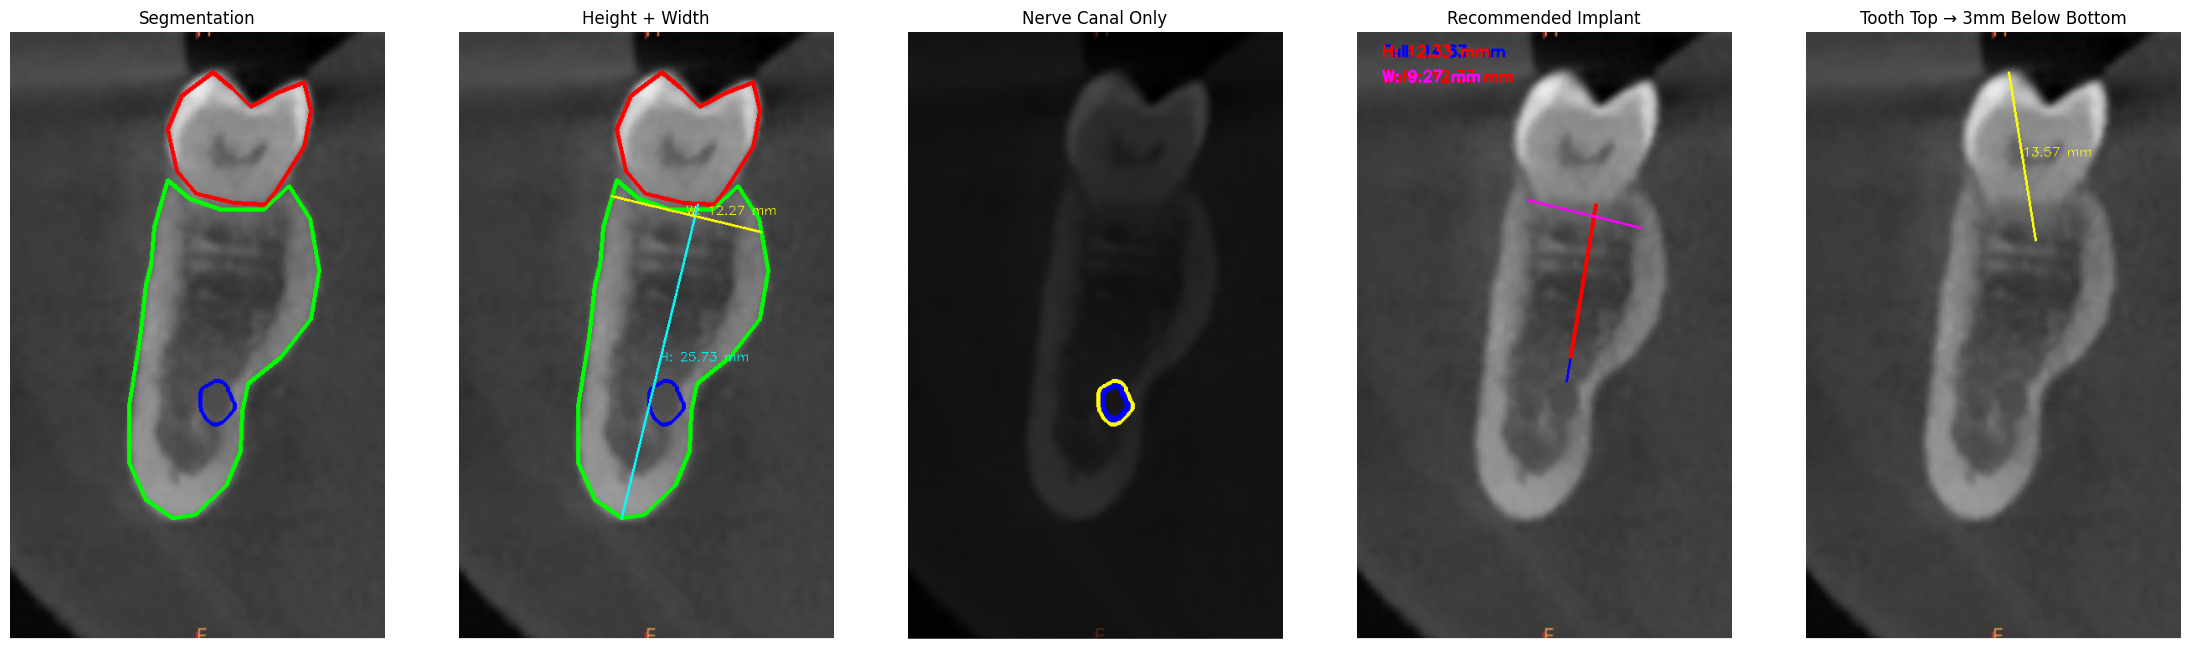

In [ ]:

# ================= IMPORTS =================
import json
import cv2
import numpy as np
import os
import matplotlib.pyplot as plt
from inference import get_model
from pycocotools import mask as maskUtils
# ================= CONFIG =================
COCO_PATH = "/content/drive/MyDrive/teethimplant/_annotations.coco.json"
IMAGE_FOLDER = "/content/drive/MyDrive/teethimplant/"

IMAGE_NUMBER = 5
PIXELS_PER_MM = 15
PX_TO_MM = 1 / PIXELS_PER_MM
MM_TO_PX = PIXELS_PER_MM

SEG_THICKNESS = 2
LINE_THICKNESS = 2
TEXT_SCALE = 0.5
TEXT_THICKNESS = 1

# ================= IMPLANT CATALOG =================
def load_implant_catalog():
    return {
        "Straumann": [(3.5,8),(3.5,10),(3.5,12),(3.5,14),(3.5,16),(3.5,18),
                      (4.0,6),(4.0,8),(4.0,10),(4.0,12),(4.0,14),(4.0,16),(4.0,18)],
        "Nobel Biocare": [(3.0,10),(3.0,13),(3.5,10),(3.5,13),(4.3,10),(4.3,13)],
        "Noris": [(3.3,8),(3.3,10),(3.75,8),(3.75,10),(4.2,8),(4.2,10)],
        "Osstem": [(3.0,10),(3.5,10),(4.3,10),(5.0,10)]
    }

def recommend_implant(section_height_mm,
                      section_width_mm,
                      nerve_mask,
                      top,
                      PX_TO_MM,
                      MM_TO_PX,
                      implant_catalog):

    implant_width_mm = max(section_width_mm - 3, 0)

    ys, xs = np.where(nerve_mask == 1)

    if len(ys) > 0:
        nerve_top_y = np.min(ys)
        safe_y = nerve_top_y - (2 * MM_TO_PX)
        implant_height_px = abs(safe_y - top[1])
        implant_height_mm = implant_height_px * PX_TO_MM
    else:
        implant_height_mm = section_height_mm

    implant_height_mm = max(implant_height_mm, 0)

    best_match = None
    best_error = float("inf")

    for company, implants in implant_catalog.items():
        for dia, length in implants:
            if dia <= implant_width_mm and length <= implant_height_mm:
                error = abs(dia - implant_width_mm) + abs(length - implant_height_mm)
                if error < best_error:
                    best_error = error
                    best_match = (company, dia, length)

    return implant_width_mm, implant_height_mm, best_match

# ================= LOAD DATA =================
with open(COCO_PATH) as f:
    coco = json.load(f)

image_files = sorted([f for f in os.listdir(IMAGE_FOLDER)
                      if f.lower().endswith((".png",".jpg",".jpeg"))])

selected_image_name = image_files[IMAGE_NUMBER-1]
print("Selected:", selected_image_name)

img_path = os.path.join(IMAGE_FOLDER, selected_image_name)
base_image = cv2.imread(img_path)
h,w = base_image.shape[:2]

image_id = None
for img in coco["images"]:
    if img["file_name"] == selected_image_name:
        image_id = img["id"]
        break

# ================= SEGMENTATION IMAGE =================
image_no_line = base_image.copy()

# ================= SEGMENTATION IMAGE (BRUSH SAFE) =================


bone_mask = np.zeros((h,w), dtype=np.uint8)
nerve_mask = np.zeros((h,w), dtype=np.uint8)

tooth_bottom = None
bone_bottom = None
bone_top = None

for ann in coco["annotations"]:
    if ann["image_id"] != image_id:
        continue

    cat = ann["category_id"]

    # -------- RLE (BRUSH TOOL) --------
    if isinstance(ann["segmentation"], dict):

        rle = ann["segmentation"]
        mask = maskUtils.decode(rle)

        if cat == 1:
            bone_mask = np.maximum(bone_mask, mask)
        elif cat == 2:
            nerve_mask = np.maximum(nerve_mask, mask)

        contours, _ = cv2.findContours(mask.astype(np.uint8),
                                       cv2.RETR_EXTERNAL,
                                       cv2.CHAIN_APPROX_SIMPLE)

        for cnt in contours:
            if cat == 1:
                cv2.drawContours(image_no_line,[cnt],-1,(0,255,0),3)
            elif cat == 2:
                cv2.drawContours(image_no_line,[cnt],-1,(255,0,0),3)

    # -------- POLYGON (TOOTH / BONE) --------
    else:
        pts = np.array(ann["segmentation"][0]).reshape(-1,2).astype(int)

        if cat == 3:
            # Create mask from polygon
            tooth_mask_img = np.zeros((h,w), dtype=np.uint8)
            cv2.fillPoly(tooth_mask_img, [pts], 1)

            # Get bottom-most row that contains tooth
            ys, xs = np.where(tooth_mask_img == 1)

            max_y = np.max(ys)

            # Get all pixels at bottom row
            bottom_xs = xs[ys == max_y]

            # True center of bottom border
            mid_x = int(np.mean(bottom_xs))
            mid_y = int(max_y)

            tooth_bottom = np.array([mid_x, mid_y])
            SHIFT_X = -14   # positive → move right, negative → move left
            tooth_bottom[0] += SHIFT_X
            cv2.polylines(image_no_line,[pts],True,(0,0,255),3)

        elif cat == 1:
            bone_bottom = pts[np.argmax(pts[:,1])]
            bone_top = pts[np.argmin(pts[:,1])]
            cv2.fillPoly(bone_mask,[pts],1)
            cv2.polylines(image_no_line,[pts],True,(0,255,0),3)

    #cv2.polylines(overlay,[pts],True,(0,255,0),SEG_THICKNESS)
# ================= NERVE ONLY IMAGE =================

# ================= NERVE ONLY IMAGE =================
nerve_only_image = base_image.copy()

# Darken background
nerve_only_image = cv2.addWeighted(nerve_only_image, 0.3,
                                   np.zeros_like(nerve_only_image), 0.7, 0)

for ann in coco["annotations"]:
    if ann["image_id"] != image_id:
        continue

    if ann["category_id"] == 2:

        if isinstance(ann["segmentation"], dict):
            rle = ann["segmentation"]
            mask = maskUtils.decode(rle)
        else:
            pts = np.array(ann["segmentation"][0]).reshape(-1,2).astype(int)
            mask = np.zeros((h,w), dtype=np.uint8)
            cv2.fillPoly(mask,[pts],1)

        # Fill nerve region
        nerve_only_image[mask == 1] = (255,0,0)

        # Draw boundary
        contours, _ = cv2.findContours(mask.astype(np.uint8),
                                       cv2.RETR_EXTERNAL,
                                       cv2.CHAIN_APPROX_SIMPLE)
        cv2.drawContours(nerve_only_image, contours, -1, (0,255,255), 3)
#image_no_line = cv2.addWeighted(overlay,0.9,image_no_line,0.1,0)

# ================= HEIGHT + WIDTH IMAGE =================
image_with_lines = image_no_line.copy()

direction = bone_bottom - tooth_bottom
direction = direction / (np.linalg.norm(direction)+1e-6)

perp = np.array([-direction[1], direction[0]])
perp = perp / (np.linalg.norm(perp)+1e-6)

# Height line
cv2.line(image_with_lines,tuple(tooth_bottom),tuple(bone_bottom),(255,255,0),2)

# Width logic (UNCHANGED)
OFFSET_PX = 15   # 3 or 4 pixels below tooth bottom
start_point = tooth_bottom.astype(float) + direction * OFFSET_PX

def walk(start, vec):
    cur = start.copy()
    last = cur.copy()
    while True:
        cur += vec
        x,y = int(round(cur[0])), int(round(cur[1]))
        if x<0 or x>=w or y<0 or y>=h or bone_mask[y,x]==0:
            break
        last = cur.copy()
    return last

edge1 = walk(start_point, perp)
edge2 = walk(start_point, -perp)

cv2.line(image_with_lines,
         tuple(edge1.astype(int)),
         tuple(edge2.astype(int)),
         (0,255,255),
         2)

width_px = np.linalg.norm(edge1-edge2)
section_width_mm = width_px * PX_TO_MM
# ---- HEIGHT MM DISPLAY ----
height_px = np.linalg.norm(bone_bottom - tooth_bottom)
height_mm = height_px * PX_TO_MM

mid_height = ((tooth_bottom + bone_bottom)/2).astype(int)

cv2.putText(image_with_lines,
            f"H: {round(height_mm,2)} mm",
            tuple(mid_height),
            cv2.FONT_HERSHEY_SIMPLEX,
            TEXT_SCALE,
            (255,255,0),
            TEXT_THICKNESS)

# ---- WIDTH MM DISPLAY ----
mid_width = ((edge1 + edge2)/2).astype(int)

cv2.putText(image_with_lines,
            f"W: {round(section_width_mm,2)} mm",
            tuple(mid_width),
            cv2.FONT_HERSHEY_SIMPLEX,
            TEXT_SCALE,
            (0,255,255),
            TEXT_THICKNESS)
# ================= 3MM IMAGE =================
image_3mm = base_image.copy()

bottom_3mm = tooth_bottom + direction*(3*MM_TO_PX)
bottom_3mm = bottom_3mm.astype(int)

cv2.line(image_3mm,tuple(tooth_bottom),tuple(bottom_3mm),(255,0,255),2)
mid_3mm = ((tooth_bottom + bottom_3mm)/2).astype(int)

cv2.putText(image_3mm,
            "3 mm",
            tuple(mid_3mm),
            cv2.FONT_HERSHEY_SIMPLEX,
            TEXT_SCALE,
            (255,0,255),
            TEXT_THICKNESS)
# ================= SECTION HEIGHT =================
section_height_px = abs(bottom_3mm[1] - bone_top[1])
section_height_mm = section_height_px * PX_TO_MM

# ================= IMPLANT RECOMMEND =================
catalog = load_implant_catalog()

implant_width_mm, implant_height_mm, best = recommend_implant(
    section_height_mm,
    section_width_mm,
    nerve_mask,
    bone_top,
    PX_TO_MM,
    MM_TO_PX,
    catalog
)

# ================= IMPLANT IMAGE =================
# ================= TRUE IMPLANT HEIGHT =================

# ================= TRUE IMPLANT HEIGHT =================

# ================= TRUE IMPLANT HEIGHT =================
# ================= TRUE IMPLANT HEIGHT =================
implant_image = base_image.copy()

ys, xs = np.where(nerve_mask == 1)

if len(ys) > 0 and tooth_bottom is not None:

    # 1️⃣ Nerve center
    nerve_center = np.array([np.mean(xs), np.mean(ys)])

    # 2️⃣ Direction from tooth bottom → nerve center
    nerve_direction = nerve_center - tooth_bottom
    nerve_direction = nerve_direction / (np.linalg.norm(nerve_direction) + 1e-6)

    # 3️⃣ Walk pixel-by-pixel toward nerve
    current = tooth_bottom.astype(float)

    while True:
        current += nerve_direction
        x, y = int(round(current[0])), int(round(current[1]))

        if x < 0 or x >= w or y < 0 or y >= h:
            break

        if nerve_mask[y, x] == 1:
            break

    # 🟦 FULL distance (to nerve border)
    nerve_touch_point = current.copy()

    cv2.line(implant_image,
             tuple(tooth_bottom.astype(int)),
             tuple(nerve_touch_point.astype(int)),
             (255,0,0), 2)   # BLUE LINE → full length to nerve

    full_height_px = np.linalg.norm(nerve_touch_point - tooth_bottom)
    full_height_mm = full_height_px * PX_TO_MM

    # 🔴 SAFE implant line (2mm before nerve)
    safe_point = nerve_touch_point - nerve_direction * (2 * MM_TO_PX)

    cv2.line(implant_image,
             tuple(tooth_bottom.astype(int)),
             tuple(safe_point.astype(int)),
             (0,0,255), 3)   # RED LINE → safe implant

    implant_height_px = np.linalg.norm(safe_point - tooth_bottom)
    implant_height_mm = implant_height_px * PX_TO_MM

    # Display values
    cv2.putText(implant_image,
                f"Full: {round(full_height_mm,2)} mm",
                (30,30),
                cv2.FONT_HERSHEY_SIMPLEX,
                0.6,
                (255,0,0),
                2)

    cv2.putText(implant_image,
                f"Safe: {round(implant_height_mm,2)} mm",
                (30,60),
                cv2.FONT_HERSHEY_SIMPLEX,
                0.6,
                (0,0,255),
                2)

else:
    implant_height_mm = 0
# ---- WIDTH: SAME AS IMAGE 2 BUT 1.5mm SHORTER EACH SIDE ----
shrink_px = 1.5 * MM_TO_PX  # 15 px

edge1_shrink = edge1 - perp * shrink_px
edge2_shrink = edge2 + perp * shrink_px

cv2.line(implant_image,
         tuple(edge1_shrink.astype(int)),
         tuple(edge2_shrink.astype(int)),
         (255,0,255),
         2)

implant_width_px = np.linalg.norm(edge1_shrink - edge2_shrink)
implant_width_mm = implant_width_px * PX_TO_MM

# ---- DISPLAY MEASUREMENTS ----
cv2.putText(implant_image,
            f"H: {round(implant_height_mm,2)} mm",
            (30,30),
            cv2.FONT_HERSHEY_SIMPLEX,
            0.6,
            (0,0,255),
            2)

cv2.putText(implant_image,
            f"W: {round(implant_width_mm,2)} mm",
            (30,60),
            cv2.FONT_HERSHEY_SIMPLEX,
            0.6,
            (255,0,255),
            2)
# ================= NEW IMAGE : TOOTH FULL HEIGHT + 3MM =================

image_tooth_measure = base_image.copy()

# ---- Get tooth top-middle ----
tooth_mask = None

for ann in coco["annotations"]:
    if ann["image_id"] == image_id and ann["category_id"] == 3:
        if not isinstance(ann["segmentation"], dict):
            pts = np.array(ann["segmentation"][0]).reshape(-1,2).astype(int)
            tooth_mask = pts
            break

if tooth_mask is not None:

    # Top-most y
    top_y = np.min(tooth_mask[:,1])

    # All x values at that y (approx)
    top_points = tooth_mask[tooth_mask[:,1] == top_y]

    if len(top_points) > 0:
        mid_x = int(np.mean(top_points[:,0]))
    else:
        mid_x = int(np.mean(tooth_mask[:,0]))

    tooth_top_mid = np.array([mid_x, top_y])

    # ---- Bottom 3mm below tooth bottom ----
    bottom_3mm_from_tooth = tooth_bottom + direction*(3*MM_TO_PX)
    bottom_3mm_from_tooth = bottom_3mm_from_tooth.astype(int)

    # ---- Draw line ----
    cv2.line(image_tooth_measure,
             tuple(tooth_top_mid),
             tuple(bottom_3mm_from_tooth),
             (0,255,255),
             2)

    # ---- Length calculation ----
    length_px = np.linalg.norm(bottom_3mm_from_tooth - tooth_top_mid)
    length_mm = length_px * PX_TO_MM

    mid_point = ((tooth_top_mid + bottom_3mm_from_tooth)/2).astype(int)

    cv2.putText(image_tooth_measure,
                f"{round(length_mm,2)} mm",
                tuple(mid_point),
                cv2.FONT_HERSHEY_SIMPLEX,
                TEXT_SCALE,
                (0,255,255),
                TEXT_THICKNESS)
# ================= DISPLAY ALL =================
# ================= TEXT OUTPUT =================

print("\n===== RECOMMENDED IMPLANT RESULT =====")
print(f"Calculated Section Height  : {round(section_height_mm,2)} mm")
print(f"Calculated Section Width   : {round(section_width_mm,2)} mm")
print(f"Recommended Implant Height : {round(implant_height_mm,2)} mm")
print(f"Recommended Implant Width  : {round(implant_width_mm,2)} mm")

if best is not None:
    company, dia_mm, length_mm = best
    print("\nBest Matching Implant From Catalog:")
    print(f"Company : {company}")
    print(f"Size    : {dia_mm} mm (Diameter) x {length_mm} mm (Length)")
else:
    print("\nNo suitable implant found in catalog.")
plt.figure(figsize=(28,10))

plt.subplot(1,5,1)
plt.imshow(cv2.cvtColor(image_no_line,cv2.COLOR_BGR2RGB))
plt.title("Segmentation")
plt.axis("off")

plt.subplot(1,5,2)
plt.imshow(cv2.cvtColor(image_with_lines,cv2.COLOR_BGR2RGB))
plt.title("Height + Width")
plt.axis("off")



plt.subplot(1,5,4)
plt.imshow(cv2.cvtColor(implant_image,cv2.COLOR_BGR2RGB))
plt.title("Recommended Implant")
plt.axis("off")

plt.subplot(1,5,5)
plt.imshow(cv2.cvtColor(image_tooth_measure,cv2.COLOR_BGR2RGB))
plt.title("Tooth Top → 3mm Below Bottom")
plt.axis("off")
plt.subplot(1,5,3)
plt.imshow(cv2.cvtColor(nerve_only_image, cv2.COLOR_BGR2RGB))
plt.title("Nerve Canal Only")
plt.axis("off")
plt.show()

Selected: Screenshot 2026-02-21 223058_png.rf.xPhk4smmYpBo6TtKFoCV.png

===== RECOMMENDED IMPLANT RESULT =====
Calculated Section Height  : 4.8 mm
Calculated Section Width   : 8.4 mm
Recommended Implant Height : 7.67 mm
Recommended Implant Width  : 5.53 mm

Best Matching Implant From Catalog:
Company : Noris
Size    : 4.2 mm (Diameter) x 8 mm (Length)


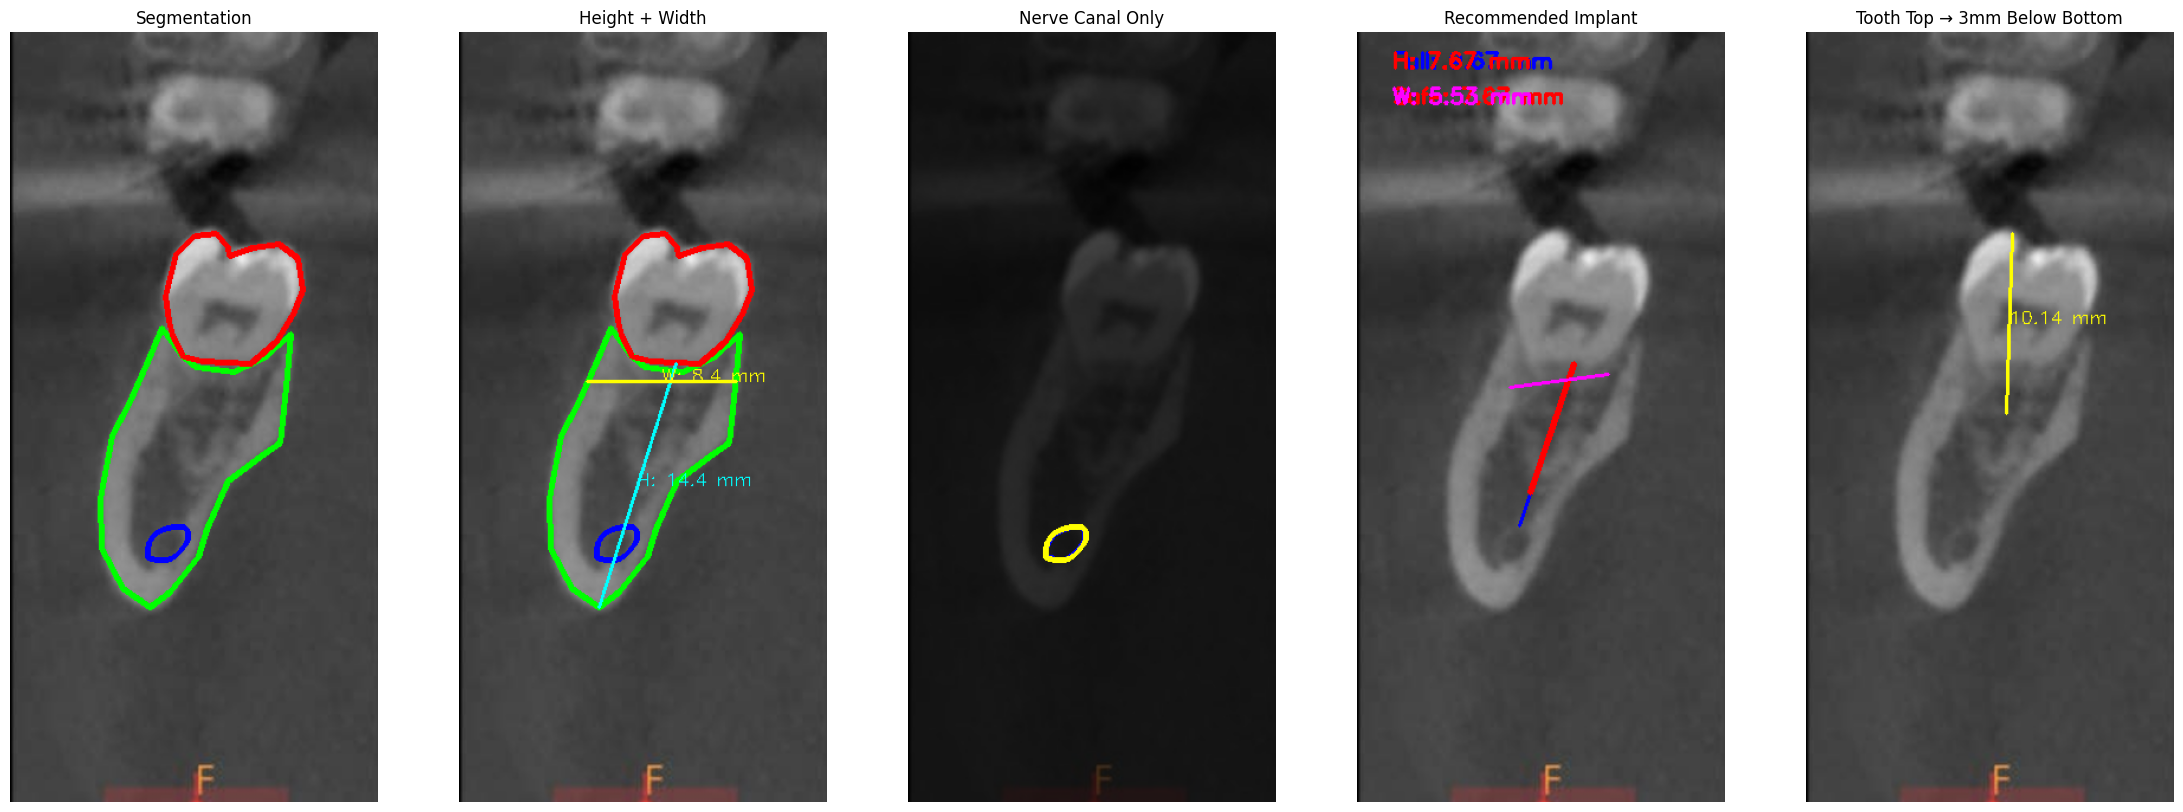

In [ ]:

# ================= IMPORTS =================
import json
import cv2
import numpy as np
import os
import matplotlib.pyplot as plt
from inference import get_model
from pycocotools import mask as maskUtils
# ================= CONFIG =================
COCO_PATH = "/content/drive/MyDrive/teethimplant/_annotations.coco.json"
IMAGE_FOLDER = "/content/drive/MyDrive/teethimplant/"

IMAGE_NUMBER = 3
PIXELS_PER_MM = 15
PX_TO_MM = 1 / PIXELS_PER_MM
MM_TO_PX = PIXELS_PER_MM

SEG_THICKNESS = 2
LINE_THICKNESS = 2
TEXT_SCALE = 0.5
TEXT_THICKNESS = 1

# ================= IMPLANT CATALOG =================
def load_implant_catalog():
    return {
        "Straumann": [(3.5,8),(3.5,10),(3.5,12),(3.5,14),(3.5,16),(3.5,18),
                      (4.0,6),(4.0,8),(4.0,10),(4.0,12),(4.0,14),(4.0,16),(4.0,18)],
        "Nobel Biocare": [(3.0,10),(3.0,13),(3.5,10),(3.5,13),(4.3,10),(4.3,13)],
        "Noris": [(3.3,8),(3.3,10),(3.75,8),(3.75,10),(4.2,8),(4.2,10)],
        "Osstem": [(3.0,10),(3.5,10),(4.3,10),(5.0,10)]
    }

def recommend_implant(section_height_mm,
                      section_width_mm,
                      nerve_mask,
                      top,
                      PX_TO_MM,
                      MM_TO_PX,
                      implant_catalog):

    implant_width_mm = max(section_width_mm - 3, 0)

    ys, xs = np.where(nerve_mask == 1)

    if len(ys) > 0:
        nerve_top_y = np.min(ys)
        safe_y = nerve_top_y - (2 * MM_TO_PX)
        implant_height_px = abs(safe_y - top[1])
        implant_height_mm = implant_height_px * PX_TO_MM
    else:
        implant_height_mm = section_height_mm

    implant_height_mm = max(implant_height_mm, 0)

    best_match = None
    best_error = float("inf")

    for company, implants in implant_catalog.items():
        for dia, length in implants:
            if dia <= implant_width_mm and length <= implant_height_mm:
                error = abs(dia - implant_width_mm) + abs(length - implant_height_mm)
                if error < best_error:
                    best_error = error
                    best_match = (company, dia, length)

    return implant_width_mm, implant_height_mm, best_match

# ================= LOAD DATA =================
with open(COCO_PATH) as f:
    coco = json.load(f)

image_files = sorted([f for f in os.listdir(IMAGE_FOLDER)
                      if f.lower().endswith((".png",".jpg",".jpeg"))])

selected_image_name = image_files[IMAGE_NUMBER-1]
print("Selected:", selected_image_name)

img_path = os.path.join(IMAGE_FOLDER, selected_image_name)
base_image = cv2.imread(img_path)
h,w = base_image.shape[:2]

image_id = None
for img in coco["images"]:
    if img["file_name"] == selected_image_name:
        image_id = img["id"]
        break

# ================= SEGMENTATION IMAGE =================
image_no_line = base_image.copy()

# ================= SEGMENTATION IMAGE (BRUSH SAFE) =================


bone_mask = np.zeros((h,w), dtype=np.uint8)
nerve_mask = np.zeros((h,w), dtype=np.uint8)

tooth_bottom = None
bone_bottom = None
bone_top = None

for ann in coco["annotations"]:
    if ann["image_id"] != image_id:
        continue

    cat = ann["category_id"]

    # -------- RLE (BRUSH TOOL) --------
    if isinstance(ann["segmentation"], dict):

        rle = ann["segmentation"]
        mask = maskUtils.decode(rle)

        if cat == 1:
            bone_mask = np.maximum(bone_mask, mask)
        elif cat == 2:
            nerve_mask = np.maximum(nerve_mask, mask)

        contours, _ = cv2.findContours(mask.astype(np.uint8),
                                       cv2.RETR_EXTERNAL,
                                       cv2.CHAIN_APPROX_SIMPLE)

        for cnt in contours:
            if cat == 1:
                cv2.drawContours(image_no_line,[cnt],-1,(0,255,0),3)
            elif cat == 2:
                cv2.drawContours(image_no_line,[cnt],-1,(255,0,0),3)

    # -------- POLYGON (TOOTH / BONE) --------
    else:
        pts = np.array(ann["segmentation"][0]).reshape(-1,2).astype(int)

        if cat == 3:
            # Create mask from polygon
            tooth_mask_img = np.zeros((h,w), dtype=np.uint8)
            cv2.fillPoly(tooth_mask_img, [pts], 1)

            # Get bottom-most row that contains tooth
            ys, xs = np.where(tooth_mask_img == 1)

            max_y = np.max(ys)

            # Get all pixels at bottom row
            bottom_xs = xs[ys == max_y]

            # True center of bottom border
            mid_x = int(np.mean(bottom_xs))
            mid_y = int(max_y)

            tooth_bottom = np.array([mid_x, mid_y])
            SHIFT_X = -15   # positive → move right, negative → move left
            tooth_bottom[0] += SHIFT_X
            cv2.polylines(image_no_line,[pts],True,(0,0,255),3)

        elif cat == 1:
            bone_bottom = pts[np.argmax(pts[:,1])]
            bone_top = pts[np.argmin(pts[:,1])]
            cv2.fillPoly(bone_mask,[pts],1)
            cv2.polylines(image_no_line,[pts],True,(0,255,0),3)

    #cv2.polylines(overlay,[pts],True,(0,255,0),SEG_THICKNESS)
# ================= NERVE ONLY IMAGE =================

# ================= NERVE ONLY IMAGE =================
nerve_only_image = base_image.copy()

# Darken background
nerve_only_image = cv2.addWeighted(nerve_only_image, 0.3,
                                   np.zeros_like(nerve_only_image), 0.7, 0)

for ann in coco["annotations"]:
    if ann["image_id"] != image_id:
        continue

    if ann["category_id"] == 2:

        if isinstance(ann["segmentation"], dict):
            rle = ann["segmentation"]
            mask = maskUtils.decode(rle)
        else:
            pts = np.array(ann["segmentation"][0]).reshape(-1,2).astype(int)
            mask = np.zeros((h,w), dtype=np.uint8)
            cv2.fillPoly(mask,[pts],1)

        # Fill nerve region
        nerve_only_image[mask == 1] = (255,0,0)

        # Draw boundary
        contours, _ = cv2.findContours(mask.astype(np.uint8),
                                       cv2.RETR_EXTERNAL,
                                       cv2.CHAIN_APPROX_SIMPLE)
        cv2.drawContours(nerve_only_image, contours, -1, (0,255,255), 3)
#image_no_line = cv2.addWeighted(overlay,0.9,image_no_line,0.1,0)

# ================= HEIGHT + WIDTH IMAGE =================
image_with_lines = image_no_line.copy()
# Draw height line (implant axis)
cv2.line(image_with_lines,
         tuple(tooth_bottom.astype(int)),
         tuple(bone_bottom.astype(int)),
         (255,255,0),
         2)
direction = bone_bottom - tooth_bottom
direction = direction / (np.linalg.norm(direction)+1e-6)

# ================= HORIZONTAL WIDTH =================

OFFSET_PX = 15   # how far below tooth bottom
y_level = int(tooth_bottom[1] + OFFSET_PX)

# Safety clamp
y_level = np.clip(y_level, 0, h-1)

# Walk LEFT
x_left = tooth_bottom[0]
while x_left > 0 and bone_mask[y_level, x_left] == 1:
    x_left -= 1

# Walk RIGHT
x_right = tooth_bottom[0]
while x_right < w-1 and bone_mask[y_level, x_right] == 1:
    x_right += 1

edge1 = np.array([x_left, y_level])
edge2 = np.array([x_right, y_level])

# Draw horizontal width line
cv2.line(image_with_lines,
         tuple(edge1),
         tuple(edge2),
         (0,255,255),
         2)

width_px = abs(x_right - x_left)
section_width_mm = width_px * PX_TO_MM

cv2.line(image_with_lines,
         tuple(edge1.astype(int)),
         tuple(edge2.astype(int)),
         (0,255,255),
         2)

width_px = np.linalg.norm(edge1-edge2)
section_width_mm = width_px * PX_TO_MM
# ---- HEIGHT MM DISPLAY ----
height_px = np.linalg.norm(bone_bottom - tooth_bottom)
height_mm = height_px * PX_TO_MM

mid_height = ((tooth_bottom + bone_bottom)/2).astype(int)

cv2.putText(image_with_lines,
            f"H: {round(height_mm,2)} mm",
            tuple(mid_height),
            cv2.FONT_HERSHEY_SIMPLEX,
            TEXT_SCALE,
            (255,255,0),
            TEXT_THICKNESS)

# ---- WIDTH MM DISPLAY ----
mid_width = ((edge1 + edge2)/2).astype(int)

cv2.putText(image_with_lines,
            f"W: {round(section_width_mm,2)} mm",
            tuple(mid_width),
            cv2.FONT_HERSHEY_SIMPLEX,
            TEXT_SCALE,
            (0,255,255),
            TEXT_THICKNESS)
# ================= 3MM IMAGE =================
image_3mm = base_image.copy()

bottom_3mm = tooth_bottom + direction*(3*MM_TO_PX)
bottom_3mm = bottom_3mm.astype(int)

cv2.line(image_3mm,tuple(tooth_bottom),tuple(bottom_3mm),(255,0,255),2)
mid_3mm = ((tooth_bottom + bottom_3mm)/2).astype(int)

cv2.putText(image_3mm,
            "3 mm",
            tuple(mid_3mm),
            cv2.FONT_HERSHEY_SIMPLEX,
            TEXT_SCALE,
            (255,0,255),
            TEXT_THICKNESS)
# ================= SECTION HEIGHT =================
section_height_px = abs(bottom_3mm[1] - bone_top[1])
section_height_mm = section_height_px * PX_TO_MM

# ================= IMPLANT RECOMMEND =================
catalog = load_implant_catalog()

implant_width_mm, implant_height_mm, best = recommend_implant(
    section_height_mm,
    section_width_mm,
    nerve_mask,
    bone_top,
    PX_TO_MM,
    MM_TO_PX,
    catalog
)

# ================= IMPLANT IMAGE =================
# ================= TRUE IMPLANT HEIGHT =================

# ================= TRUE IMPLANT HEIGHT =================

# ================= TRUE IMPLANT HEIGHT =================
# ================= TRUE IMPLANT HEIGHT =================
implant_image = base_image.copy()

ys, xs = np.where(nerve_mask == 1)

if len(ys) > 0 and tooth_bottom is not None:

    # 1️⃣ Nerve center
    nerve_center = np.array([np.mean(xs), np.mean(ys)])

    # 2️⃣ Direction from tooth bottom → nerve center
    nerve_direction = nerve_center - tooth_bottom
    nerve_direction = nerve_direction / (np.linalg.norm(nerve_direction) + 1e-6)

    # 3️⃣ Walk pixel-by-pixel toward nerve
    current = tooth_bottom.astype(float)

    while True:
        current += nerve_direction
        x, y = int(round(current[0])), int(round(current[1]))

        if x < 0 or x >= w or y < 0 or y >= h:
            break

        if nerve_mask[y, x] == 1:
            break

    # 🟦 FULL distance (to nerve border)
    nerve_touch_point = current.copy()

    cv2.line(implant_image,
             tuple(tooth_bottom.astype(int)),
             tuple(nerve_touch_point.astype(int)),
             (255,0,0), 2)   # BLUE LINE → full length to nerve

    full_height_px = np.linalg.norm(nerve_touch_point - tooth_bottom)
    full_height_mm = full_height_px * PX_TO_MM

    # 🔴 SAFE implant line (2mm before nerve)
    safe_point = nerve_touch_point - nerve_direction * (2 * MM_TO_PX)

    cv2.line(implant_image,
             tuple(tooth_bottom.astype(int)),
             tuple(safe_point.astype(int)),
             (0,0,255), 3)   # RED LINE → safe implant

    implant_height_px = np.linalg.norm(safe_point - tooth_bottom)
    implant_height_mm = implant_height_px * PX_TO_MM

    # Display values
    cv2.putText(implant_image,
                f"Full: {round(full_height_mm,2)} mm",
                (30,30),
                cv2.FONT_HERSHEY_SIMPLEX,
                0.6,
                (255,0,0),
                2)

    cv2.putText(implant_image,
                f"Safe: {round(implant_height_mm,2)} mm",
                (30,60),
                cv2.FONT_HERSHEY_SIMPLEX,
                0.6,
                (0,0,255),
                2)

else:
    implant_height_mm = 0
# ---- WIDTH: SAME AS IMAGE 2 BUT 1.5mm SHORTER EACH SIDE ----
shrink_px = 1.5 * MM_TO_PX  # 15 px

edge1_shrink = edge1 - perp * shrink_px
edge2_shrink = edge2 + perp * shrink_px

cv2.line(implant_image,
         tuple(edge1_shrink.astype(int)),
         tuple(edge2_shrink.astype(int)),
         (255,0,255),
         2)

implant_width_px = np.linalg.norm(edge1_shrink - edge2_shrink)
implant_width_mm = implant_width_px * PX_TO_MM

# ---- DISPLAY MEASUREMENTS ----
cv2.putText(implant_image,
            f"H: {round(implant_height_mm,2)} mm",
            (30,30),
            cv2.FONT_HERSHEY_SIMPLEX,
            0.6,
            (0,0,255),
            2)

cv2.putText(implant_image,
            f"W: {round(implant_width_mm,2)} mm",
            (30,60),
            cv2.FONT_HERSHEY_SIMPLEX,
            0.6,
            (255,0,255),
            2)
# ================= NEW IMAGE : TOOTH FULL HEIGHT + 3MM =================

image_tooth_measure = base_image.copy()

# ---- Get tooth top-middle ----
tooth_mask = None

for ann in coco["annotations"]:
    if ann["image_id"] == image_id and ann["category_id"] == 3:
        if not isinstance(ann["segmentation"], dict):
            pts = np.array(ann["segmentation"][0]).reshape(-1,2).astype(int)
            tooth_mask = pts
            break

if tooth_mask is not None:

    # Top-most y
    top_y = np.min(tooth_mask[:,1])

    # All x values at that y (approx)
    top_points = tooth_mask[tooth_mask[:,1] == top_y]

    if len(top_points) > 0:
        mid_x = int(np.mean(top_points[:,0]))
    else:
        mid_x = int(np.mean(tooth_mask[:,0]))

    tooth_top_mid = np.array([mid_x, top_y])

    # ---- Bottom 3mm below tooth bottom ----
    bottom_3mm_from_tooth = tooth_bottom + direction*(3*MM_TO_PX)
    bottom_3mm_from_tooth = bottom_3mm_from_tooth.astype(int)

    # ---- Draw line ----
    cv2.line(image_tooth_measure,
             tuple(tooth_top_mid),
             tuple(bottom_3mm_from_tooth),
             (0,255,255),
             2)

    # ---- Length calculation ----
    length_px = np.linalg.norm(bottom_3mm_from_tooth - tooth_top_mid)
    length_mm = length_px * PX_TO_MM

    mid_point = ((tooth_top_mid + bottom_3mm_from_tooth)/2).astype(int)

    cv2.putText(image_tooth_measure,
                f"{round(length_mm,2)} mm",
                tuple(mid_point),
                cv2.FONT_HERSHEY_SIMPLEX,
                TEXT_SCALE,
                (0,255,255),
                TEXT_THICKNESS)
# ================= DISPLAY ALL =================
# ================= TEXT OUTPUT =================

print("\n===== RECOMMENDED IMPLANT RESULT =====")
print(f"Calculated Section Height  : {round(section_height_mm,2)} mm")
print(f"Calculated Section Width   : {round(section_width_mm,2)} mm")
print(f"Recommended Implant Height : {round(implant_height_mm,2)} mm")
print(f"Recommended Implant Width  : {round(implant_width_mm,2)} mm")

if best is not None:
    company, dia_mm, length_mm = best
    print("\nBest Matching Implant From Catalog:")
    print(f"Company : {company}")
    print(f"Size    : {dia_mm} mm (Diameter) x {length_mm} mm (Length)")
else:
    print("\nNo suitable implant found in catalog.")
plt.figure(figsize=(28,10))

plt.subplot(1,5,1)
plt.imshow(cv2.cvtColor(image_no_line,cv2.COLOR_BGR2RGB))
plt.title("Segmentation")
plt.axis("off")

plt.subplot(1,5,2)
plt.imshow(cv2.cvtColor(image_with_lines,cv2.COLOR_BGR2RGB))
plt.title("Height + Width")
plt.axis("off")



plt.subplot(1,5,4)
plt.imshow(cv2.cvtColor(implant_image,cv2.COLOR_BGR2RGB))
plt.title("Recommended Implant")
plt.axis("off")

plt.subplot(1,5,5)
plt.imshow(cv2.cvtColor(image_tooth_measure,cv2.COLOR_BGR2RGB))
plt.title("Tooth Top → 3mm Below Bottom")
plt.axis("off")
plt.subplot(1,5,3)
plt.imshow(cv2.cvtColor(nerve_only_image, cv2.COLOR_BGR2RGB))
plt.title("Nerve Canal Only")
plt.axis("off")
plt.show()

Selected: Screenshot 2026-02-21 223058_png.rf.xPhk4smmYpBo6TtKFoCV.png

===== RECOMMENDED IMPLANT RESULT =====
Calculated Section Height  : 5.7 mm
Calculated Section Width   : 4.3 mm
Recommended Implant Height : 11.08 mm
Recommended Implant Width  : 1.3 mm

No suitable implant found in catalog.


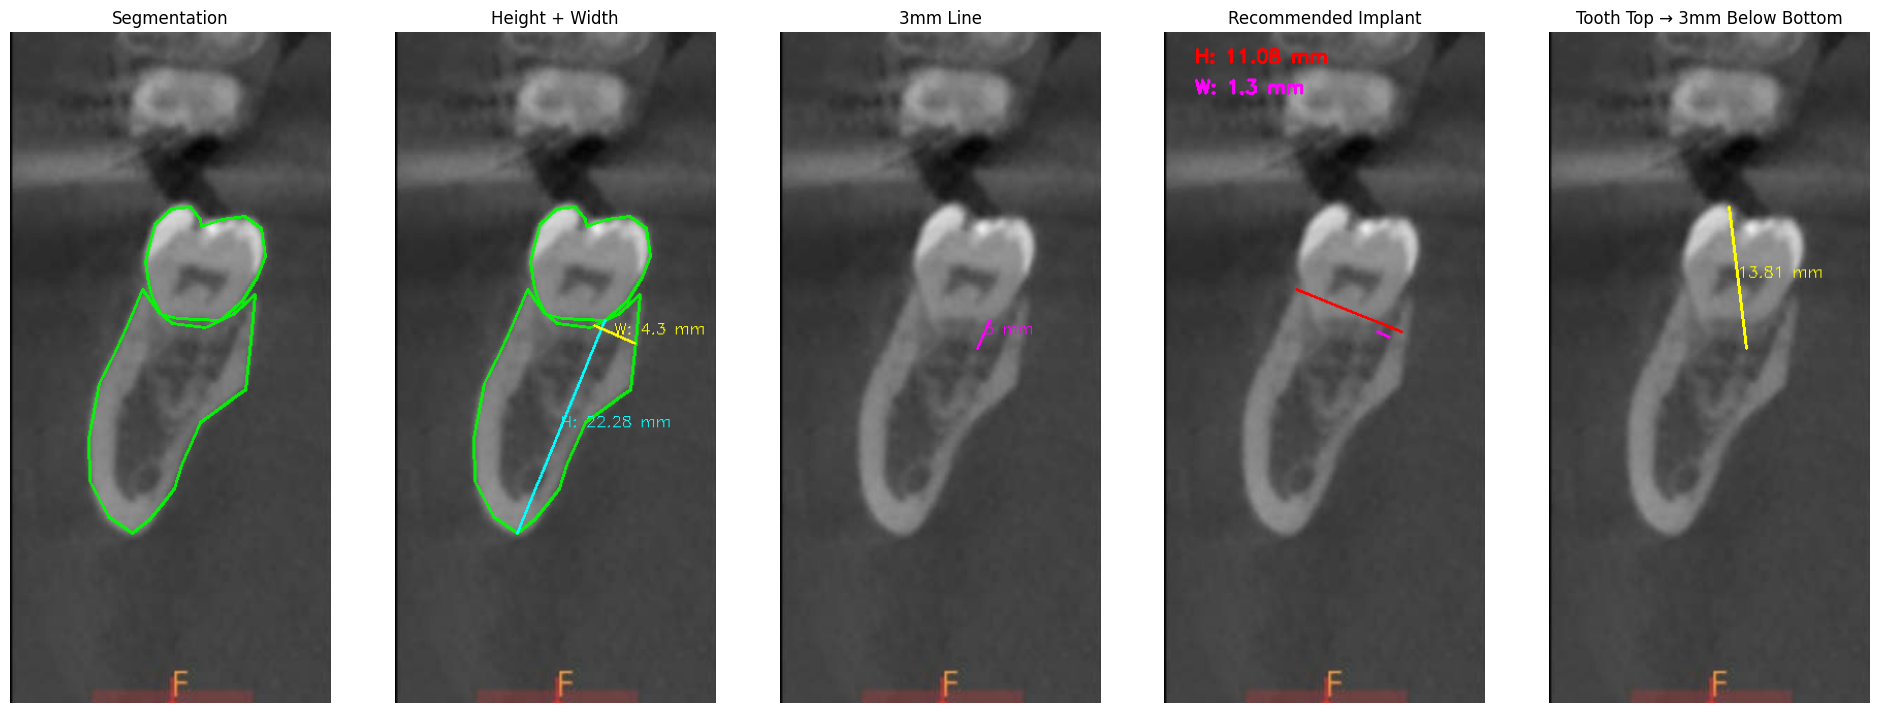

In [ ]:

# ================= IMPORTS =================
import json
import cv2
import numpy as np
import os
import matplotlib.pyplot as plt
from inference import get_model

# ================= CONFIG =================
COCO_PATH = "/content/drive/MyDrive/teethimplant/_annotations.coco.json"
IMAGE_FOLDER = "/content/drive/MyDrive/teethimplant/"

IMAGE_NUMBER = 3
PIXELS_PER_MM = 10
PX_TO_MM = 1 / PIXELS_PER_MM
MM_TO_PX = PIXELS_PER_MM

SEG_THICKNESS = 2
LINE_THICKNESS = 2
TEXT_SCALE = 0.5
TEXT_THICKNESS = 1

# ================= IMPLANT CATALOG =================
def load_implant_catalog():
    return {
        "Straumann": [(3.5,8),(3.5,10),(3.5,12),(3.5,14),(3.5,16),(3.5,18),
                      (4.0,6),(4.0,8),(4.0,10),(4.0,12),(4.0,14),(4.0,16),(4.0,18)],
        "Nobel Biocare": [(3.0,10),(3.0,13),(3.5,10),(3.5,13),(4.3,10),(4.3,13)],
        "Noris": [(3.3,8),(3.3,10),(3.75,8),(3.75,10),(4.2,8),(4.2,10)],
        "Osstem": [(3.0,10),(3.5,10),(4.3,10),(5.0,10)]
    }

def recommend_implant(section_height_mm,
                      section_width_mm,
                      nerve_mask,
                      top,
                      PX_TO_MM,
                      MM_TO_PX,
                      implant_catalog):

    implant_width_mm = max(section_width_mm - 3, 0)

    ys, xs = np.where(nerve_mask == 1)

    if len(ys) > 0:
        nerve_top_y = np.min(ys)
        safe_y = nerve_top_y - (2 * MM_TO_PX)
        implant_height_px = abs(safe_y - top[1])
        implant_height_mm = implant_height_px * PX_TO_MM
    else:
        implant_height_mm = section_height_mm

    implant_height_mm = max(implant_height_mm, 0)

    best_match = None
    best_error = float("inf")

    for company, implants in implant_catalog.items():
        for dia, length in implants:
            if dia <= implant_width_mm and length <= implant_height_mm:
                error = abs(dia - implant_width_mm) + abs(length - implant_height_mm)
                if error < best_error:
                    best_error = error
                    best_match = (company, dia, length)

    return implant_width_mm, implant_height_mm, best_match

# ================= LOAD DATA =================
with open(COCO_PATH) as f:
    coco = json.load(f)

image_files = sorted([f for f in os.listdir(IMAGE_FOLDER)
                      if f.lower().endswith((".png",".jpg",".jpeg"))])

selected_image_name = image_files[IMAGE_NUMBER-1]
print("Selected:", selected_image_name)

img_path = os.path.join(IMAGE_FOLDER, selected_image_name)
base_image = cv2.imread(img_path)
h,w = base_image.shape[:2]

image_id = None
for img in coco["images"]:
    if img["file_name"] == selected_image_name:
        image_id = img["id"]
        break

# ================= SEGMENTATION IMAGE =================
image_no_line = base_image.copy()
overlay = image_no_line.copy()

tooth_bottom = None
bone_bottom = None
bone_top = None

bone_mask = np.zeros((h,w), dtype=np.uint8)
nerve_mask = np.zeros((h,w), dtype=np.uint8)

for ann in coco["annotations"]:
    if ann["image_id"] != image_id:
        continue

    if isinstance(ann["segmentation"], dict):
        continue

    pts = np.array(ann["segmentation"][0]).reshape(-1,2).astype(int)

    if ann["category_id"] == 3:
        tooth_bottom = pts[np.argmax(pts[:,1])]
    elif ann["category_id"] == 1:
        bone_bottom = pts[np.argmax(pts[:,1])]
        bone_top = pts[np.argmin(pts[:,1])]
        cv2.fillPoly(bone_mask,[pts],1)
    elif ann["category_id"] == 2:
        cv2.fillPoly(nerve_mask,[pts],1)

    cv2.polylines(overlay,[pts],True,(0,255,0),SEG_THICKNESS)

image_no_line = cv2.addWeighted(overlay,0.9,image_no_line,0.1,0)

# ================= HEIGHT + WIDTH IMAGE =================
image_with_lines = image_no_line.copy()

direction = bone_bottom - tooth_bottom
direction = direction / (np.linalg.norm(direction)+1e-6)

perp = np.array([-direction[1], direction[0]])
perp = perp / (np.linalg.norm(perp)+1e-6)

# Height line
cv2.line(image_with_lines,tuple(tooth_bottom),tuple(bone_bottom),(255,255,0),2)

# Width logic (UNCHANGED)
start_point = tooth_bottom.astype(float) + direction*9

def walk(start, vec):
    cur = start.copy()
    last = cur.copy()
    while True:
        cur += vec
        x,y = int(round(cur[0])), int(round(cur[1]))
        if x<0 or x>=w or y<0 or y>=h or bone_mask[y,x]==0:
            break
        last = cur.copy()
    return last

edge1 = walk(start_point, perp)
edge2 = walk(start_point, -perp)

cv2.line(image_with_lines,
         tuple(edge1.astype(int)),
         tuple(edge2.astype(int)),
         (0,255,255),
         2)

width_px = np.linalg.norm(edge1-edge2)
section_width_mm = width_px * PX_TO_MM
# ---- HEIGHT MM DISPLAY ----
height_px = np.linalg.norm(bone_bottom - tooth_bottom)
height_mm = height_px * PX_TO_MM

mid_height = ((tooth_bottom + bone_bottom)/2).astype(int)

cv2.putText(image_with_lines,
            f"H: {round(height_mm,2)} mm",
            tuple(mid_height),
            cv2.FONT_HERSHEY_SIMPLEX,
            TEXT_SCALE,
            (255,255,0),
            TEXT_THICKNESS)

# ---- WIDTH MM DISPLAY ----
mid_width = ((edge1 + edge2)/2).astype(int)

cv2.putText(image_with_lines,
            f"W: {round(section_width_mm,2)} mm",
            tuple(mid_width),
            cv2.FONT_HERSHEY_SIMPLEX,
            TEXT_SCALE,
            (0,255,255),
            TEXT_THICKNESS)
# ================= 3MM IMAGE =================
image_3mm = base_image.copy()

bottom_3mm = tooth_bottom + direction*(3*MM_TO_PX)
bottom_3mm = bottom_3mm.astype(int)

cv2.line(image_3mm,tuple(tooth_bottom),tuple(bottom_3mm),(255,0,255),2)
mid_3mm = ((tooth_bottom + bottom_3mm)/2).astype(int)

cv2.putText(image_3mm,
            "3 mm",
            tuple(mid_3mm),
            cv2.FONT_HERSHEY_SIMPLEX,
            TEXT_SCALE,
            (255,0,255),
            TEXT_THICKNESS)
# ================= SECTION HEIGHT =================
section_height_px = abs(bottom_3mm[1] - bone_top[1])
section_height_mm = section_height_px * PX_TO_MM

# ================= IMPLANT RECOMMEND =================
catalog = load_implant_catalog()

implant_width_mm, implant_height_mm, best = recommend_implant(
    section_height_mm,
    section_width_mm,
    nerve_mask,
    bone_top,
    PX_TO_MM,
    MM_TO_PX,
    catalog
)

# ================= IMPLANT IMAGE =================
# ================= IMPLANT IMAGE =================
implant_image = base_image.copy()

# Unit direction from bone_top → tooth_bottom
implant_direction = tooth_bottom - bone_top
implant_direction = implant_direction / (np.linalg.norm(implant_direction) + 1e-6)

# Top of implant = top-most bone point
implant_top = bone_top.astype(float)

# Bottom of implant = 3mm BELOW tooth bottom along same axis
implant_bottom = tooth_bottom.astype(float) + implant_direction * (3 * MM_TO_PX)

# Draw implant height line
cv2.line(implant_image,
         tuple(implant_top.astype(int)),
         tuple(implant_bottom.astype(int)),
         (0,0,255),
         2)

# Calculate implant height
implant_height_px = np.linalg.norm(implant_bottom - implant_top)
implant_height_mm = implant_height_px * PX_TO_MM

# ---- WIDTH: SAME AS IMAGE 2 BUT 1.5mm SHORTER EACH SIDE ----
shrink_px = 1.5 * MM_TO_PX  # 15 px

edge1_shrink = edge1 - perp * shrink_px
edge2_shrink = edge2 + perp * shrink_px

cv2.line(implant_image,
         tuple(edge1_shrink.astype(int)),
         tuple(edge2_shrink.astype(int)),
         (255,0,255),
         2)

implant_width_px = np.linalg.norm(edge1_shrink - edge2_shrink)
implant_width_mm = implant_width_px * PX_TO_MM

# ---- DISPLAY MEASUREMENTS ----
cv2.putText(implant_image,
            f"H: {round(implant_height_mm,2)} mm",
            (30,30),
            cv2.FONT_HERSHEY_SIMPLEX,
            0.6,
            (0,0,255),
            2)

cv2.putText(implant_image,
            f"W: {round(implant_width_mm,2)} mm",
            (30,60),
            cv2.FONT_HERSHEY_SIMPLEX,
            0.6,
            (255,0,255),
            2)
# ================= NEW IMAGE : TOOTH FULL HEIGHT + 3MM =================

image_tooth_measure = base_image.copy()

# ---- Get tooth top-middle ----
tooth_mask = None

for ann in coco["annotations"]:
    if ann["image_id"] == image_id and ann["category_id"] == 3:
        if not isinstance(ann["segmentation"], dict):
            pts = np.array(ann["segmentation"][0]).reshape(-1,2).astype(int)
            tooth_mask = pts
            break

if tooth_mask is not None:

    # Top-most y
    top_y = np.min(tooth_mask[:,1])

    # All x values at that y (approx)
    top_points = tooth_mask[tooth_mask[:,1] == top_y]

    if len(top_points) > 0:
        mid_x = int(np.mean(top_points[:,0]))
    else:
        mid_x = int(np.mean(tooth_mask[:,0]))

    tooth_top_mid = np.array([mid_x, top_y])

    # ---- Bottom 3mm below tooth bottom ----
    bottom_3mm_from_tooth = tooth_bottom + direction*(3*MM_TO_PX)
    bottom_3mm_from_tooth = bottom_3mm_from_tooth.astype(int)

    # ---- Draw line ----
    cv2.line(image_tooth_measure,
             tuple(tooth_top_mid),
             tuple(bottom_3mm_from_tooth),
             (0,255,255),
             2)

    # ---- Length calculation ----
    length_px = np.linalg.norm(bottom_3mm_from_tooth - tooth_top_mid)
    length_mm = length_px * PX_TO_MM

    mid_point = ((tooth_top_mid + bottom_3mm_from_tooth)/2).astype(int)

    cv2.putText(image_tooth_measure,
                f"{round(length_mm,2)} mm",
                tuple(mid_point),
                cv2.FONT_HERSHEY_SIMPLEX,
                TEXT_SCALE,
                (0,255,255),
                TEXT_THICKNESS)
# ================= DISPLAY ALL =================
# ================= TEXT OUTPUT =================

print("\n===== RECOMMENDED IMPLANT RESULT =====")
print(f"Calculated Section Height  : {round(section_height_mm,2)} mm")
print(f"Calculated Section Width   : {round(section_width_mm,2)} mm")
print(f"Recommended Implant Height : {round(implant_height_mm,2)} mm")
print(f"Recommended Implant Width  : {round(implant_width_mm,2)} mm")

if best is not None:
    company, dia_mm, length_mm = best
    print("\nBest Matching Implant From Catalog:")
    print(f"Company : {company}")
    print(f"Size    : {dia_mm} mm (Diameter) x {length_mm} mm (Length)")
else:
    print("\nNo suitable implant found in catalog.")
plt.figure(figsize=(24,10))

plt.subplot(1,5,1)
plt.imshow(cv2.cvtColor(image_no_line,cv2.COLOR_BGR2RGB))
plt.title("Segmentation")
plt.axis("off")

plt.subplot(1,5,2)
plt.imshow(cv2.cvtColor(image_with_lines,cv2.COLOR_BGR2RGB))
plt.title("Height + Width")
plt.axis("off")

plt.subplot(1,5,3)
plt.imshow(cv2.cvtColor(image_3mm,cv2.COLOR_BGR2RGB))
plt.title("3mm Line")
plt.axis("off")

plt.subplot(1,5,4)
plt.imshow(cv2.cvtColor(implant_image,cv2.COLOR_BGR2RGB))
plt.title("Recommended Implant")
plt.axis("off")

plt.subplot(1,5,5)
plt.imshow(cv2.cvtColor(image_tooth_measure,cv2.COLOR_BGR2RGB))
plt.title("Tooth Top → 3mm Below Bottom")
plt.axis("off")

plt.show()